In [ ]:
!pip install -q kaggle


In [ ]:
!mkdir -p ~/.kaggle
!cp "/content/kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat '/content/kaggle (1).json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d shyambhu/hands-and-palm-images-dataset

Dataset URL: https://www.kaggle.com/datasets/shyambhu/hands-and-palm-images-dataset
License(s): DbCL-1.0
100% 634M/634M [00:08<00:00, 78.4MB/s]



In [ ]:
!unzip -q hands-and-palm-images-dataset.zip -d palm_dataset

In [ ]:
!ls palm_dataset

HandInfo.csv  Hands


In [ ]:
# Fix for protobuf version incompatibility with MediaPipe
!pip install --upgrade protobuf==3.20.3

# IMPORTANT: After running this cell, please restart the Colab runtime
# (Runtime -> Restart runtime) and then re-run the previous cell (7e14d3e7).


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 3.20.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
wandb 0.28.0 requires protobuf!=5.28.0,!=5.29.0,<8,>4.21.0, but you have protobuf 3.20.3 which is incompatible.
google-cloud-spanner 3.68.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
proto-plus 1.28.1 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-dataproc 5.28.0 requires protobuf<8.0.0,>=4.2

In [ ]:
# First, uninstall potentially conflicting packages to clean up the environment.
# The -y flag confirms all prompts.
!pip uninstall -y mediapipe protobuf

# Now, install mediapipe. This should automatically fetch and install a protobuf
# version that is compatible with mediapipe.
# For mediapipe 0.10.14, this means protobuf in the range [4.25.3, 5).
!pip install mediapipe

# IMPORTANT: After running this cell, you MUST restart the Colab runtime
# (Runtime -> Restart runtime) and then re-run the cell with the MediaPipe import
# and landmark detection code (cell 7e14d3e7).


Found existing installation: protobuf 3.20.3
Uninstalling protobuf-3.20.3:
  Successfully uninstalled protobuf-3.20.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, which is not installed.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, which is not installed.
orbax-checkpoint 0.12.1 requires protobuf, which is not installed.
tensorflow-hub 0.16.1 requires protobuf>=3.19.6, which is not installed.
grain 0.2.18 requires protobuf>=5.28.3, which is not installed.
tensorboard 2.20.0 requires protobuf!=4.24.0,>=3.1

In [ ]:
import mediapipe as mp

print("MediaPipe Version:", mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))

MediaPipe Version: 1.0.0
Has solutions: False


In [ ]:
import mediapipe as mp

print(mp)
print(mp.__file__)
print(dir(mp))

<module 'mediapipe' from '/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py'>
/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py
['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


### Using MediaPipe Tasks Vision API for Hand Landmark Detection



In [ ]:
# 1. Download the pre-trained Hand Landmarker model
# This model detects the 21 hand landmarks.
!wget -q -O hand_landmarker.task - https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
print("Hand Landmarker model downloaded.")

# 2. Import necessary modules from MediaPipe Tasks
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 3. Configure the options for the HandLandmarker task
# We set the running mode to 'image' for processing static images
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)

# 4. Create a HandLandmarker object
# This object will be used to detect hand landmarks in images.
hand_landmarker = vision.HandLandmarker.create_from_options(options)
print("Hand Landmarker initialized successfully.")


Hand Landmarker model downloaded.
Hand Landmarker initialized successfully.


Now that the `HandLandmarker` is initialized, we can proceed with loading images from your `palm_dataset`, detecting the landmarks, drawing them, and displaying the results. This code is an adaptation of your previous request to use the new API.

Found 11076 images in 'palm_dataset/Hands'.


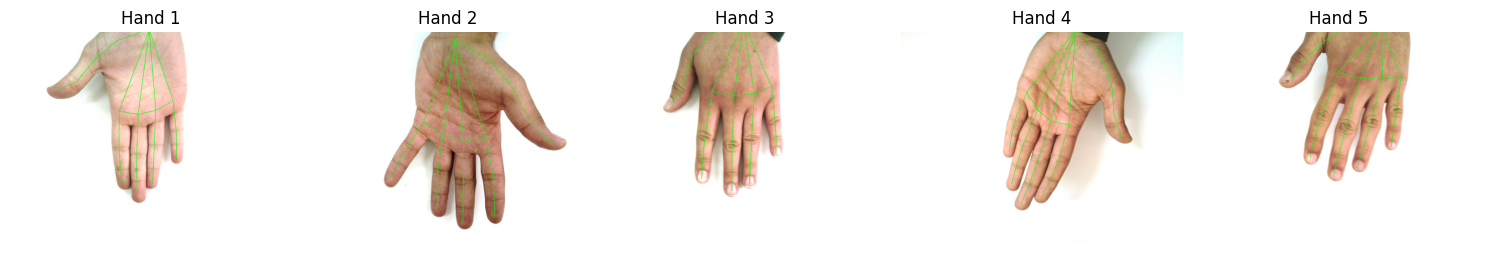

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt
from glob import glob
import mediapipe as mp # Only need the top-level mediapipe for mp.Image, etc.

# Define hand connections based on MediaPipe's standard 21 hand landmarks
# These are tuples of (start_landmark_index, end_landmark_index)
HAND_CONNECTIONS = frozenset([
    (0, 1), (1, 2), (2, 3), (3, 4),        # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),        # Index finger
    (0, 9), (9, 10), (10, 11), (11, 12),   # Middle finger
    (0, 13), (13, 14), (14, 15), (15, 16), # Ring finger
    (0, 17), (17, 18), (18, 19), (19, 20), # Pinky finger
    (5, 9), (9, 13), (13, 17)              # Palm base connections
])

def draw_landmarks_custom(image, landmarks, connections=None,
                          landmark_color=(255, 0, 0), landmark_radius=2,
                          connection_color=(0, 255, 0), connection_thickness=2):
    if not landmarks:
        return

    # Convert normalized landmarks to pixel coordinates
    h, w, _ = image.shape
    points = []
    for landmark in landmarks:
        cx, cy = int(landmark.x * w), int(landmark.y * h)
        points.append((cx, cy))
        cv2.circle(image, (cx, cy), landmark_radius, landmark_color, -1) # -1 for filled circle

    if connections:
        for connection in connections:
            start_idx, end_idx = connection
            if start_idx < len(points) and end_idx < len(points):
                start_point = points[start_idx]
                end_point = points[end_idx]
                cv2.line(image, start_point, end_point, connection_color, connection_thickness)

# Define the directory where your images are located
image_dir = 'palm_dataset/Hands'
# Use glob to find all JPG images recursively within the Hands directory
image_paths = glob(os.path.join(image_dir, '**', '*.jpg'), recursive=True)

print(f"Found {len(image_paths)} images in '{image_dir}'.")

# Prepare to display sample images
num_samples_to_display = 5
displayed_count = 0

plt.figure(figsize=(15, 10)) # Set up a figure to display multiple images

for i, image_path in enumerate(image_paths):
    if displayed_count >= num_samples_to_display:
        break # Stop after displaying enough samples

    # 5. Load image as MediaPipe Image format
    # MediaPipe Tasks APIs require images to be in their specific `mp.Image` format.
    # OpenCV's imread reads in BGR, so convert to RGB before creating mp.Image.
    cv_image = cv2.imread(image_path)
    if cv_image is None:
        print(f"Warning: Could not read image {image_path}. Skipping.")
        continue

    # Convert BGR to RGB
    rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
    # Corrected: Use mp.ImageFormat.SRGB for standard RGB images
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)

    # 6. Detect hand landmarks
    # Perform landmark detection on the MediaPipe image.
    detection_result = hand_landmarker.detect(mp_image)

    # Create a copy of the original RGB image to draw on
    image_drawn = rgb_image.copy()

    # 7. Draw landmarks on sample images using the custom function
    if detection_result.hand_landmarks:
        for hand_landmarks_for_one_hand in detection_result.hand_landmarks:
            draw_landmarks_custom(
                image_drawn,
                hand_landmarks_for_one_hand, # Pass the list of NormalizedLandmark directly
                connections=HAND_CONNECTIONS, # Use our defined connections
                landmark_color=(255, 0, 0), # Red landmarks
                landmark_radius=2,
                connection_color=(0, 255, 0), # Green connections
                connection_thickness=2
            )

        # 8. Display at least 5 images with detected landmarks
        plt.subplot(1, num_samples_to_display, displayed_count + 1) # Create subplot for current image
        plt.imshow(image_drawn)
        plt.title(f"Hand {displayed_count+1}")
        plt.axis('off') # Hide axes for cleaner display
        displayed_count += 1

plt.tight_layout()
plt.show()

# Close the HandLandmarker to release resources
hand_landmarker.close()

if displayed_count == 0:
    print("No hands were detected in the sampled images for display.")

In [ ]:
import pandas as pd
import cv2
import os
import mediapipe as mp
from glob import glob
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Re-initialize the HandLandmarker as it was closed in the previous cell
# This model detects the 21 hand landmarks.
# We set the running mode to 'image' for processing static images
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
hand_landmarker = vision.HandLandmarker.create_from_options(options)
print("Hand Landmarker re-initialized for CSV generation.")

# Re-define image_dir and image_paths to ensure they are available
image_dir = 'palm_dataset/Hands'
image_paths = glob(os.path.join(image_dir, '**', '*.jpg'), recursive=True)

# List to store all landmark data for CSV
all_landmark_data = []
processed_images_count = 0

print(f"Starting landmark extraction for {len(image_paths)} images...")

for image_path in image_paths:
    # Load image as MediaPipe Image format
    cv_image = cv2.imread(image_path)
    if cv_image is None:
        print(f"Warning: Could not read image {image_path}. Skipping.")
        continue

    rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)

    # Detect hand landmarks
    detection_result = hand_landmarker.detect(mp_image)

    # Skip if no hands are detected
    if not detection_result.hand_landmarks:
        continue

    # Assuming one hand per image, as per the HandLandmarkerOptions (num_hands=1)
    # Each `hand_landmarks_for_one_hand` is a list of NormalizedLandmark objects
    for hand_landmarks_for_one_hand in detection_result.hand_landmarks:
        row = {'filename': os.path.basename(image_path)}
        # Extract x, y, z coordinates for each of the 21 landmarks
        for i, landmark in enumerate(hand_landmarks_for_one_hand):
            row[f'landmark_{i}_x'] = landmark.x
            row[f'landmark_{i}_y'] = landmark.y
            row[f'landmark_{i}_z'] = landmark.z
        all_landmark_data.append(row)
        processed_images_count += 1

# Create a DataFrame from the collected data
df_landmarks = pd.DataFrame(all_landmark_data)

# Define the output CSV file path
output_csv_path = 'palm_landmarks.csv'

# Save the DataFrame to a CSV file
df_landmarks.to_csv(output_csv_path, index=False)

print(f"Finished processing. Total images with detected hands: {processed_images_count}")
print(f"Landmark data saved to: {output_csv_path}")

# Close the HandLandmarker to release resources after all processing is done
hand_landmarker.close()

Hand Landmarker re-initialized for CSV generation.
Starting landmark extraction for 11076 images...
Finished processing. Total images with detected hands: 10587
Landmark data saved to: palm_landmarks.csv


In [ ]:
!ls

'archive (2).zip'       hands-and-palm-images-dataset.zip   palm_landmarks.csv
 hand_landmarker.task   palm_dataset			    sample_data


In [ ]:
import pandas as pd

df = pd.read_csv("palm_landmarks.csv")

print("Shape:", df.shape)
df.head()

Shape: (10587, 64)


,filename,landmark_0_x,landmark_0_y,landmark_0_z,landmark_1_x,landmark_1_y,landmark_1_z,landmark_2_x,landmark_2_y,landmark_2_z,...,landmark_17_z,landmark_18_x,landmark_18_y,landmark_18_z,landmark_19_x,landmark_19_y,landmark_19_z,landmark_20_x,landmark_20_y,landmark_20_z
0,Hand_0007199.jpg,0.493998,-0.009068,3.258928e-07,0.379093,0.045719,-0.036188,0.299672,0.136268,-0.050328,...,-0.023741,0.588482,0.456932,-0.041888,0.591171,0.532932,-0.049301,0.591010,0.604351,-0.054273
1,Hand_0011391.jpg,0.524604,0.040689,6.926329e-07,0.649943,0.138395,-0.079201,0.737175,0.283073,-0.115954,...,-0.032401,0.357951,0.543624,-0.059699,0.323392,0.623537,-0.085091,0.293660,0.699836,-0.104412
2,Hand_0007896.jpg,0.494484,-0.042710,4.740144e-07,0.376259,0.012047,-0.023430,0.307908,0.124479,-0.042175,...,-0.076698,0.605912,0.410033,-0.108597,0.610091,0.500221,-0.125020,0.609474,0.577800,-0.134020
3,Hand_0000543.jpg,0.619663,-0.007117,1.953787e-07,0.706944,0.102474,-0.055591,0.748441,0.267728,-0.083932,...,-0.066251,0.407519,0.406707,-0.092214,0.393523,0.488944,-0.109199,0.383469,0.567432,-0.123211
4,Hand_0004113.jpg,0.650958,-0.029383,1.092302e-06,0.534806,-0.026829,-0.050531,0.449273,0.048222,-0.093957,...,-0.137028,0.704127,0.366068,-0.184290,0.694024,0.463035,-0.209295,0.685509,0.544519,-0.225412


# Tarot Dataset Processing

In [ ]:
import os

# Current directory ke files dekho
print(os.listdir())

['.config', 'archive (2).zip', 'palm_dataset', 'hand_landmarker.task', 'palm_landmarks.csv', 'hands-and-palm-images-dataset.zip', 'sample_data']


In [ ]:
!ls

'archive (2).zip'       hands-and-palm-images-dataset.zip   palm_landmarks.csv
 hand_landmarker.task   palm_dataset			    sample_data


In [ ]:
!kaggle datasets download -d lsind18/tarot-json

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 4, in <module>
    from kaggle.api.kaggle_api_extended import KaggleApi
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 53, in <module>
    from google.protobuf import field_mask_pb2
ModuleNotFoundError: No module named 'google.protobuf'


In [ ]:
!ls

'archive (2).zip'       hands-and-palm-images-dataset.zip   palm_landmarks.csv
 hand_landmarker.task   palm_dataset			    sample_data


In [ ]:
!unzip "archive (2).zip" -d tarot_dataset

Archive:  archive (2).zip
  inflating: tarot_dataset/cards/c01.jpg  
  inflating: tarot_dataset/cards/c02.jpg  
  inflating: tarot_dataset/cards/c03.jpg  
  inflating: tarot_dataset/cards/c04.jpg  
  inflating: tarot_dataset/cards/c05.jpg  
  inflating: tarot_dataset/cards/c06.jpg  
  inflating: tarot_dataset/cards/c07.jpg  
  inflating: tarot_dataset/cards/c08.jpg  
  inflating: tarot_dataset/cards/c09.jpg  
  inflating: tarot_dataset/cards/c10.jpg  
  inflating: tarot_dataset/cards/c11.jpg  
  inflating: tarot_dataset/cards/c12.jpg  
  inflating: tarot_dataset/cards/c13.jpg  
  inflating: tarot_dataset/cards/c14.jpg  
  inflating: tarot_dataset/cards/m00.jpg  
  inflating: tarot_dataset/cards/m01.jpg  
  inflating: tarot_dataset/cards/m02.jpg  
  inflating: tarot_dataset/cards/m03.jpg  
  inflating: tarot_dataset/cards/m04.jpg  
  inflating: tarot_dataset/cards/m05.jpg  
  inflating: tarot_dataset/cards/m06.jpg  
  inflating: tarot_dataset/cards/m07.jpg  
  inflating: tarot_dataset/c

In [ ]:
!ls tarot_dataset
!ls tarot_dataset/cards | head

cards  tarot-images.json
c01.jpg
c02.jpg
c03.jpg
c04.jpg
c05.jpg
c06.jpg
c07.jpg
c08.jpg
c09.jpg
c10.jpg


In [ ]:
!ls

'archive (2).zip'		     palm_dataset	  tarot_dataset
 hand_landmarker.task		     palm_landmarks.csv
 hands-and-palm-images-dataset.zip   sample_data


In [ ]:
!unzip -l "archive (2).zip" | head -30

Archive:  archive (2).zip
  Length      Date    Time    Name
---------  ---------- -----   ----
    90041  2019-10-26 20:54   cards/c01.jpg
   100746  2019-10-26 20:54   cards/c02.jpg
   109969  2019-10-26 20:54   cards/c03.jpg
   111112  2019-10-26 20:54   cards/c04.jpg
    80769  2019-10-26 20:54   cards/c05.jpg
   111130  2019-10-26 20:54   cards/c06.jpg
   105736  2019-10-26 20:54   cards/c07.jpg
    95570  2019-10-26 20:54   cards/c08.jpg
    96297  2019-10-26 20:54   cards/c09.jpg
    99435  2019-10-26 20:54   cards/c10.jpg
    89143  2019-10-26 20:54   cards/c11.jpg
    89221  2019-10-26 20:54   cards/c12.jpg
   110511  2019-10-26 20:54   cards/c13.jpg
   102180  2019-10-26 20:54   cards/c14.jpg
    96447  2019-10-26 20:54   cards/m00.jpg
    97765  2019-10-26 20:54   cards/m01.jpg
   105951  2019-10-26 20:54   cards/m02.jpg
   117392  2019-10-26 20:54   cards/m03.jpg
   117343  2019-10-26 20:54   cards/m04.jpg
   113709  2019-10-26 20:54   cards/m05.jpg
   115390  2019-10-26 20

In [ ]:
!unzip "archive (2).zip" -d tarot_dataset

Archive:  archive (2).zip
replace tarot_dataset/cards/c01.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: tarot_dataset/cards/c01.jpg  
  inflating: tarot_dataset/cards/c02.jpg  
  inflating: tarot_dataset/cards/c03.jpg  
  inflating: tarot_dataset/cards/c04.jpg  
  inflating: tarot_dataset/cards/c05.jpg  
  inflating: tarot_dataset/cards/c06.jpg  
  inflating: tarot_dataset/cards/c07.jpg  
  inflating: tarot_dataset/cards/c08.jpg  
  inflating: tarot_dataset/cards/c09.jpg  
  inflating: tarot_dataset/cards/c10.jpg  
  inflating: tarot_dataset/cards/c11.jpg  
  inflating: tarot_dataset/cards/c12.jpg  
  inflating: tarot_dataset/cards/c13.jpg  
  inflating: tarot_dataset/cards/c14.jpg  
  inflating: tarot_dataset/cards/m00.jpg  
  inflating: tarot_dataset/cards/m01.jpg  
  inflating: tarot_dataset/cards/m02.jpg  
  inflating: tarot_dataset/cards/m03.jpg  
  inflating: tarot_dataset/cards/m04.jpg  
  inflating: tarot_dataset/cards/m05.jpg  
  inflating: tarot_dataset/cards/m06.

In [ ]:
!ls tarot_dataset
!ls tarot_dataset/cards | head

cards  tarot-images.json
c01.jpg
c02.jpg
c03.jpg
c04.jpg
c05.jpg
c06.jpg
c07.jpg
c08.jpg
c09.jpg
c10.jpg


In [ ]:
import json
import pandas as pd

with open("tarot_dataset/tarot-images.json", "r") as f:
    tarot = json.load(f)

print(type(tarot))
print("Total records:", len(tarot))

<class 'dict'>
Total records: 2


In [ ]:
print(tarot.keys())

dict_keys(['description', 'cards'])


In [ ]:
for key in tarot.keys():
    print(key)
    print(type(tarot[key]))
    if isinstance(tarot[key], list):
        print("Length:", len(tarot[key]))
    print("-"*40)

description
<class 'str'>
----------------------------------------
cards
<class 'list'>
Length: 78
----------------------------------------


In [ ]:
df = pd.DataFrame(tarot["cards"])

print("Shape:", df.shape)
df.head()

Shape: (78, 16)


,name,number,arcana,suit,img,fortune_telling,keywords,meanings,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]","{'light': ['Freeing yourself from limitation',...",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]","{'light': ['Taking appropriate action', 'Recei...",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",{'light': ['Listening to your feelings and int...,The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]","{'light': ['Nurturing yourself and others', 'B...",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]","{'light': ['Exercising authority', 'Defining l...",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,NaN,NaN


In [ ]:
print(df.columns.tolist())

['name', 'number', 'arcana', 'suit', 'img', 'fortune_telling', 'keywords', 'meanings', 'Archetype', 'Hebrew Alphabet', 'Numerology', 'Elemental', 'Mythical/Spiritual', 'Questions to Ask', 'Astrology', 'Affirmation']


Dataset Information


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   meanings            78 non-null     object
 8   Archetype           22 non-null     object
 9   Hebrew Alphabet     22 non-null     object
 10  Numerology          62 non-null     object
 11  Elemental           38 non-null     object
 12  Mythical/Spiritual  22 non-null     object
 13  Questions to Ask    78 non-null     object
 14  Astrology           40 non-null     object
 15  Affirmation         56 non-null     object
dtypes: object(16)
memory usage: 

Missing Values Check

In [ ]:
print(df.isnull().sum())

name                   0
number                 0
arcana                 0
suit                   0
img                    0
fortune_telling        0
keywords               0
meanings               0
Archetype             56
Hebrew Alphabet       56
Numerology            16
Elemental             40
Mythical/Spiritual    56
Questions to Ask       0
Astrology             38
Affirmation           22
dtype: int64


Arcana Distribution

In [ ]:
print(df["arcana"].value_counts())

arcana
Minor Arcana    56
Major Arcana    22
Name: count, dtype: int64


Suit Distribution

In [ ]:
print(df["suit"].value_counts())

suit
Trump        22
Cups         14
Swords       14
Wands        14
Pentacles    14
Name: count, dtype: int64


Sample Card Details

In [ ]:
print(df.loc[0])

name                                                           The Fool
number                                                                0
arcana                                                     Major Arcana
suit                                                              Trump
img                                                             m00.jpg
fortune_telling       [Watch for new projects and new beginnings, Pr...
keywords                      [freedom, faith, inexperience, innocence]
meanings              {'light': ['Freeing yourself from limitation',...
Archetype                                             The Divine Madman
Hebrew Alphabet                                              Aleph/Ox/1
Numerology                            0 (off the scale; pure potential)
Elemental                                                           Air
Mythical/Spiritual    Adam before the fall. Christ as a wandering ho...
Questions to Ask      [What would I do if I felt free to take a 

Save Clean CSV

In [ ]:
df.to_csv("tarot_cards.csv", index=False)

print("CSV Saved Successfully!")

CSV Saved Successfully!


In [ ]:
import pandas as pd

# Palm dataset load
palm_df = pd.read_csv("palm_landmarks.csv")

print(palm_df.shape)

palm_df.head()

(10587, 64)


,filename,landmark_0_x,landmark_0_y,landmark_0_z,landmark_1_x,landmark_1_y,landmark_1_z,landmark_2_x,landmark_2_y,landmark_2_z,...,landmark_17_z,landmark_18_x,landmark_18_y,landmark_18_z,landmark_19_x,landmark_19_y,landmark_19_z,landmark_20_x,landmark_20_y,landmark_20_z
0,Hand_0007199.jpg,0.493998,-0.009068,3.258928e-07,0.379093,0.045719,-0.036188,0.299672,0.136268,-0.050328,...,-0.023741,0.588482,0.456932,-0.041888,0.591171,0.532932,-0.049301,0.591010,0.604351,-0.054273
1,Hand_0011391.jpg,0.524604,0.040689,6.926329e-07,0.649943,0.138395,-0.079201,0.737175,0.283073,-0.115954,...,-0.032401,0.357951,0.543624,-0.059699,0.323392,0.623537,-0.085091,0.293660,0.699836,-0.104412
2,Hand_0007896.jpg,0.494484,-0.042710,4.740144e-07,0.376259,0.012047,-0.023430,0.307908,0.124479,-0.042175,...,-0.076698,0.605912,0.410033,-0.108597,0.610091,0.500221,-0.125020,0.609474,0.577800,-0.134020
3,Hand_0000543.jpg,0.619663,-0.007117,1.953787e-07,0.706944,0.102474,-0.055591,0.748441,0.267728,-0.083932,...,-0.066251,0.407519,0.406707,-0.092214,0.393523,0.488944,-0.109199,0.383469,0.567432,-0.123211
4,Hand_0004113.jpg,0.650958,-0.029383,1.092302e-06,0.534806,-0.026829,-0.050531,0.449273,0.048222,-0.093957,...,-0.137028,0.704127,0.366068,-0.184290,0.694024,0.463035,-0.209295,0.685509,0.544519,-0.225412


In [ ]:
import glob

images = glob.glob("palm_dataset/Hands/**/*.jpg", recursive=True)

print("Total Images:", len(images))
print("First Image:", images[0])

Total Images: 11076
First Image: palm_dataset/Hands/Hands/Hand_0007199.jpg


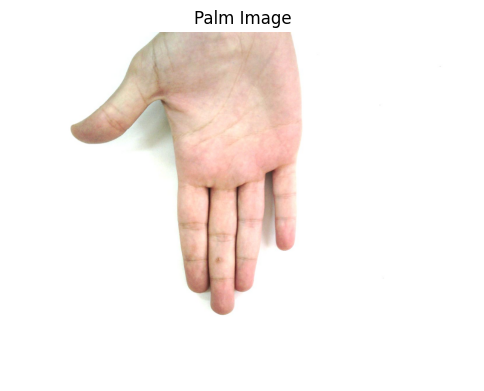

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load first palm image
img = cv2.imread(images[0])

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Palm Image")
plt.axis("off")
plt.show()

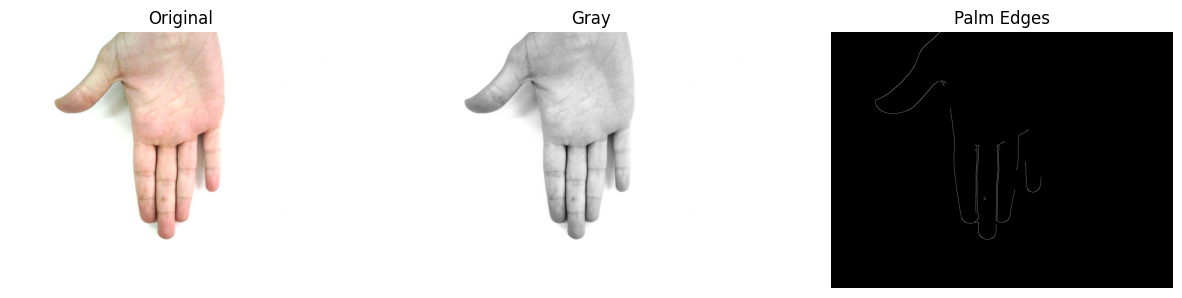

In [ ]:
# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Detect Edges
edges = cv2.Canny(blur, 50, 150)

# Display Results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges, cmap="gray")
plt.title("Palm Edges")
plt.axis("off")

plt.show()

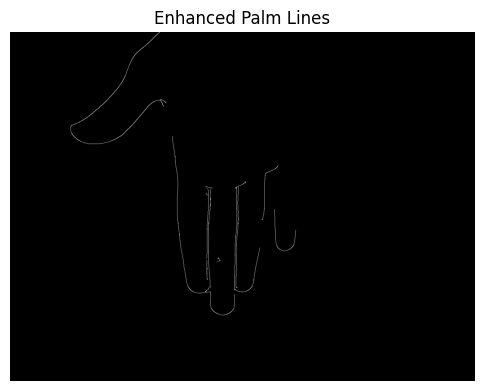

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Morphological Closing to connect broken edges
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
enhanced = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(6,6))
plt.imshow(enhanced, cmap="gray")
plt.title("Enhanced Palm Lines")
plt.axis("off")
plt.show()

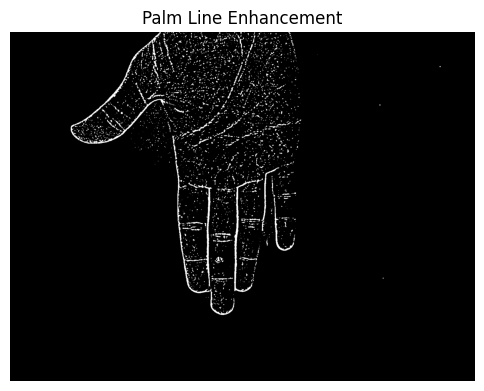

In [ ]:
import cv2
import matplotlib.pyplot as plt

# CLAHE for better contrast
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray2 = clahe.apply(gray)

# Gaussian Blur
blur = cv2.GaussianBlur(gray2, (5,5), 0)

# Adaptive Threshold
thresh = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15,
    5
)

plt.figure(figsize=(6,6))
plt.imshow(thresh, cmap="gray")
plt.title("Palm Line Enhancement")
plt.axis("off")
plt.show()

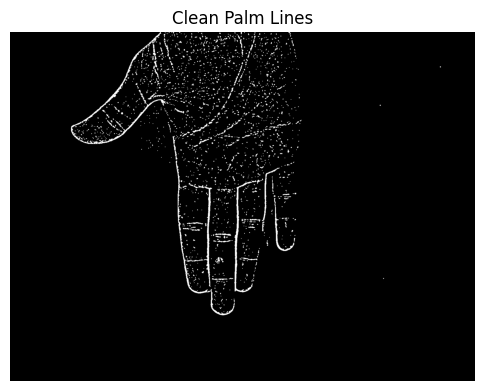

In [ ]:
# Morphological Opening
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(6,6))
plt.imshow(clean, cmap="gray")
plt.title("Clean Palm Lines")
plt.axis("off")
plt.show()

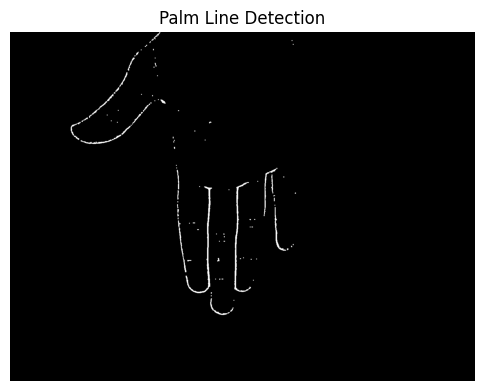

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Adaptive Threshold
thresh = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21,
    8
)

# Remove small noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Slightly connect palm lines
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(6,6))
plt.imshow(clean, cmap="gray")
plt.title("Palm Line Detection")
plt.axis("off")
plt.show()

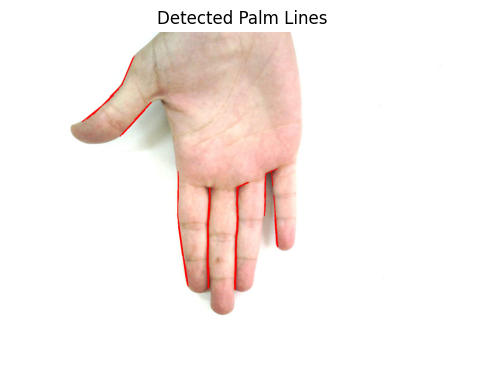

In [ ]:
import numpy as np

lines = cv2.HoughLinesP(
    clean,
    1,
    np.pi/180,
    threshold=80,
    minLineLength=40,
    maxLineGap=15
)

line_img = img_rgb.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line   # <-- line[0] hata diya
        cv2.line(line_img, (x1, y1), (x2, y2), (255,0,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(line_img)
plt.title("Detected Palm Lines")
plt.axis("off")
plt.show()

In [ ]:
import pandas as pd

# Load landmark dataset
df = pd.read_csv("palm_landmarks.csv")

print("Dataset Shape:", df.shape)
print()

# Remove filename column
X = df.drop("filename", axis=1)

print("Feature Shape:", X.shape)

X.head()

Dataset Shape: (10587, 64)

Feature Shape: (10587, 63)


,landmark_0_x,landmark_0_y,landmark_0_z,landmark_1_x,landmark_1_y,landmark_1_z,landmark_2_x,landmark_2_y,landmark_2_z,landmark_3_x,...,landmark_17_z,landmark_18_x,landmark_18_y,landmark_18_z,landmark_19_x,landmark_19_y,landmark_19_z,landmark_20_x,landmark_20_y,landmark_20_z
0,0.493998,-0.009068,3.258928e-07,0.379093,0.045719,-0.036188,0.299672,0.136268,-0.050328,0.235681,...,-0.023741,0.588482,0.456932,-0.041888,0.591171,0.532932,-0.049301,0.591010,0.604351,-0.054273
1,0.524604,0.040689,6.926329e-07,0.649943,0.138395,-0.079201,0.737175,0.283073,-0.115954,0.795292,...,-0.032401,0.357951,0.543624,-0.059699,0.323392,0.623537,-0.085091,0.293660,0.699836,-0.104412
2,0.494484,-0.042710,4.740144e-07,0.376259,0.012047,-0.023430,0.307908,0.124479,-0.042175,0.278581,...,-0.076698,0.605912,0.410033,-0.108597,0.610091,0.500221,-0.125020,0.609474,0.577800,-0.134020
3,0.619663,-0.007117,1.953787e-07,0.706944,0.102474,-0.055591,0.748441,0.267728,-0.083932,0.756297,...,-0.066251,0.407519,0.406707,-0.092214,0.393523,0.488944,-0.109199,0.383469,0.567432,-0.123211
4,0.650958,-0.029383,1.092302e-06,0.534806,-0.026829,-0.050531,0.449273,0.048222,-0.093957,0.381846,...,-0.137028,0.704127,0.366068,-0.184290,0.694024,0.463035,-0.209295,0.685509,0.544519,-0.225412


In [ ]:
from sklearn.preprocessing import StandardScaler

# Convert to float
X = X.astype("float32")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Shape:", X_scaled.shape)

Scaled Shape: (10587, 63)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Shape:", X_pca.shape)

PCA Shape: (10587, 2)


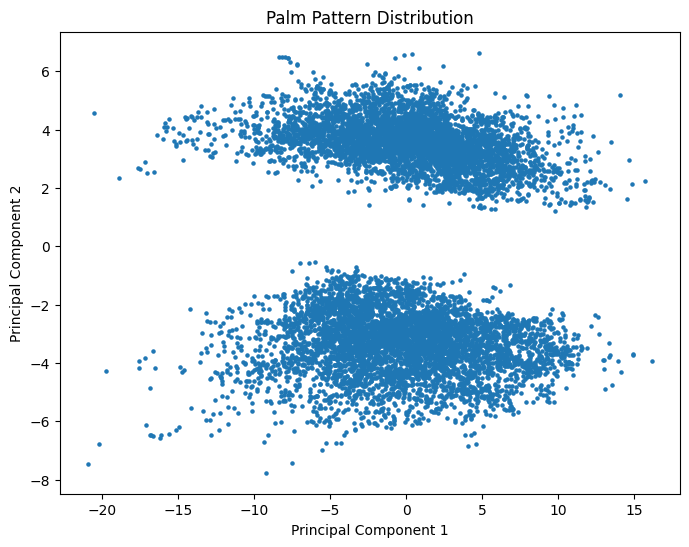

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=5
)

plt.title("Palm Pattern Distribution")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Create KMeans model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Train model
kmeans.fit(X_scaled)

print("KMeans Model Trained Successfully!")

KMeans Model Trained Successfully!


In [ ]:
clusters = kmeans.predict(X_scaled)

print(clusters[:20])

[2 3 2 1 4 1 3 1 3 0 3 0 1 2 4 3 2 1 2 0]


In [ ]:
palm_df["Cluster"] = clusters

print(palm_df["Cluster"].value_counts())

Cluster
3    2540
2    2434
1    2347
0    2256
4    1010
Name: count, dtype: int64


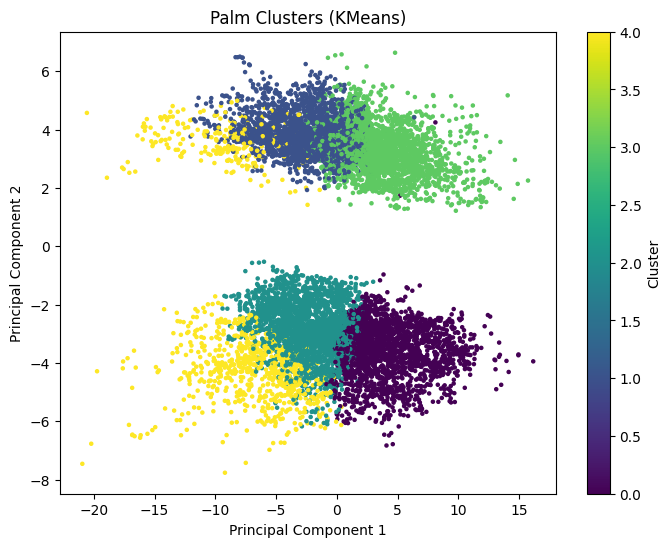

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=5
)

plt.title("Palm Clusters (KMeans)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
print(palm_df["Cluster"].value_counts().sort_index())

Cluster
0    2256
1    2347
2    2434
3    2540
4    1010
Name: count, dtype: int64


In [ ]:
cluster_summary = palm_df.groupby("Cluster").mean(numeric_only=True)

print(cluster_summary)

         landmark_0_x  landmark_0_y  landmark_0_z  landmark_1_x  landmark_1_y  \
Cluster                                                                         
0            0.539672      0.075096  4.157674e-07      0.416259      0.129750   
1            0.525816     -0.038000  1.807869e-07      0.628160      0.057591   
2            0.572745      0.002696  4.686802e-07      0.456926      0.041380   
3            0.556507      0.050879  1.586875e-07      0.661307      0.159532   
4            0.581164     -0.009246  6.940625e-07      0.510319      0.031128   

         landmark_1_z  landmark_2_x  landmark_2_y  landmark_2_z  landmark_3_x  \
Cluster                                                                         
0           -0.033923      0.335599      0.252493     -0.041498      0.293224   
1           -0.029764      0.674476      0.189989     -0.050284      0.686055   
2           -0.033249      0.376844      0.140565     -0.049312      0.328850   
3           -0.041701      

In [ ]:
cluster_summary.to_csv("palm_cluster_summary.csv")

print("Cluster Summary Saved Successfully!")

Cluster Summary Saved Successfully!


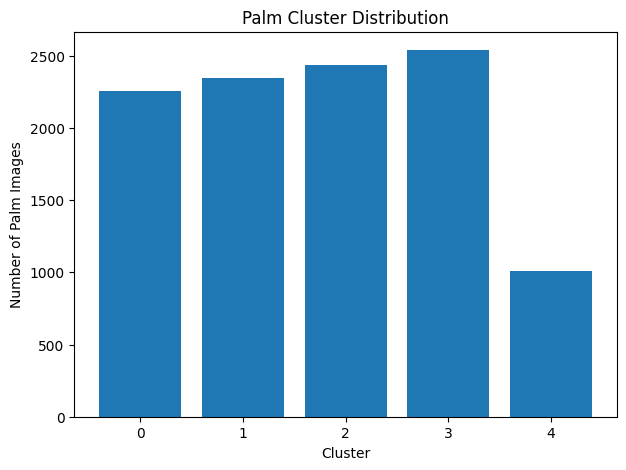

In [ ]:
import matplotlib.pyplot as plt

cluster_counts = palm_df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title("Palm Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Palm Images")

plt.show()

In [ ]:
print(type(clusters))
print(len(clusters))

<class 'numpy.ndarray'>
10587


MILESTONE-3

In [ ]:
cluster_meaning = {
    0: {
        "personality": "Creative and Independent",
        "career": "Suitable for innovation, startups and leadership.",
        "relationship": "Loyal but emotionally reserved."
    },

    1: {
        "personality": "Analytical Thinker",
        "career": "Excellent in Engineering and Research.",
        "relationship": "Trust builds slowly but deeply."
    },

    2: {
        "personality": "Confident Leader",
        "career": "Management, Business and Administration.",
        "relationship": "Protective and responsible."
    },

    3: {
        "personality": "Emotional and Caring",
        "career": "Healthcare, Teaching, Social Work.",
        "relationship": "Very affectionate and understanding."
    },

    4: {
        "personality": "Balanced Personality",
        "career": "Can adapt to multiple career paths.",
        "relationship": "Maintains harmony in relationships."
    }
}

In [ ]:
print(cluster_meaning)

{0: {'personality': 'Creative and Independent', 'career': 'Suitable for innovation, startups and leadership.', 'relationship': 'Loyal but emotionally reserved.'}, 1: {'personality': 'Analytical Thinker', 'career': 'Excellent in Engineering and Research.', 'relationship': 'Trust builds slowly but deeply.'}, 2: {'personality': 'Confident Leader', 'career': 'Management, Business and Administration.', 'relationship': 'Protective and responsible.'}, 3: {'personality': 'Emotional and Caring', 'career': 'Healthcare, Teaching, Social Work.', 'relationship': 'Very affectionate and understanding.'}, 4: {'personality': 'Balanced Personality', 'career': 'Can adapt to multiple career paths.', 'relationship': 'Maintains harmony in relationships.'}}


In [ ]:
import pandas as pd

# Palm dataset load
palm_df = pd.read_csv("palm_landmarks.csv")

# Cluster add
palm_df["Cluster"] = clusters

# Check karo
print(palm_df[["filename", "Cluster"]].head())

           filename  Cluster
0  Hand_0007199.jpg        2
1  Hand_0011391.jpg        3
2  Hand_0007896.jpg        2
3  Hand_0000543.jpg        1
4  Hand_0004113.jpg        4


In [ ]:
# Cluster ko Personality, Career aur Relationship se map

palm_df["Personality"] = palm_df["Cluster"].map(
    lambda x: cluster_meaning[x]["personality"]
)

palm_df["Career"] = palm_df["Cluster"].map(
    lambda x: cluster_meaning[x]["career"]
)

palm_df["Relationship"] = palm_df["Cluster"].map(
    lambda x: cluster_meaning[x]["relationship"]
)

palm_df[[
    "filename",
    "Cluster",
    "Personality",
    "Career",
    "Relationship"
]].head()

,filename,Cluster,Personality,Career,Relationship
0,Hand_0007199.jpg,2,Confident Leader,"Management, Business and Administration.",Protective and responsible.
1,Hand_0011391.jpg,3,Emotional and Caring,"Healthcare, Teaching, Social Work.",Very affectionate and understanding.
2,Hand_0007896.jpg,2,Confident Leader,"Management, Business and Administration.",Protective and responsible.
3,Hand_0000543.jpg,1,Analytical Thinker,Excellent in Engineering and Research.,Trust builds slowly but deeply.
4,Hand_0004113.jpg,4,Balanced Personality,Can adapt to multiple career paths.,Maintains harmony in relationships.


In [ ]:
# Tarot Dataset Load

tarot_df = pd.read_csv("tarot_cards.csv")

print("Total Tarot Cards:", len(tarot_df))

tarot_df[["name", "arcana", "suit"]].head()

Total Tarot Cards: 78


,name,arcana,suit
0,The Fool,Major Arcana,Trump
1,The Magician,Major Arcana,Trump
2,The High Priestess,Major Arcana,Trump
3,The Empress,Major Arcana,Trump
4,The Emperor,Major Arcana,Trump


In [ ]:
# First Tarot Card Details

print("Card Name :", tarot_df.loc[0, "name"])
print("Arcana    :", tarot_df.loc[0, "arcana"])
print("Suit       :", tarot_df.loc[0, "suit"])
print("\nKeywords:")
print(tarot_df.loc[0, "keywords"])

print("\nFortune Telling:")
print(tarot_df.loc[0, "fortune_telling"])

print("\nMeanings:")
print(tarot_df.loc[0, "meanings"])

Card Name : The Fool
Arcana    : Major Arcana
Suit       : Trump

Keywords:
['freedom', 'faith', 'inexperience', 'innocence']

Fortune Telling:
['Watch for new projects and new beginnings', 'Prepare to take something on faith', 'Something new comes your way; go for it']

Meanings:
{'light': ['Freeing yourself from limitation', 'Expressing joy and youthful vigor', 'Being open-minded', 'Taking a leap of faith', 'Attuning yourself to your instincts', 'Being eager or curious', 'Exploring your potential', 'Embracing innovation and change'], 'shadow': ['Being gullible and naive', 'Taking unnecessary risks', 'Failing to be serious when required', 'Being silly or distracted', 'Lacking experience', 'Failing to honor well-established traditions and limits', 'Behaving inappropriately']}


In [ ]:
def generate_ai_reading(palm_row, tarot_row):

    print("="*60)
    print("         AI PALMISTRY & TAROT REPORT")
    print("="*60)

    print("\nPalm Analysis")
    print("----------------------------")
    print("Personality :", palm_row["Personality"])
    print("Career      :", palm_row["Career"])
    print("Relationship:", palm_row["Relationship"])

    print("\nTarot Card")
    print("----------------------------")
    print("Card :", tarot_row["name"])
    print("Arcana :", tarot_row["arcana"])

    print("\nKeywords")
    print("----------------------------")
    print(", ".join(eval(tarot_row["keywords"])))

    meanings = eval(tarot_row["meanings"])

    print("\nPositive Meaning")
    print("----------------------------")
    print(meanings["light"][0])

    print("\nAI Combined Insight")
    print("----------------------------")

    print(
        f"Your palm indicates a {palm_row['Personality'].lower()} personality. "
        f"The tarot card '{tarot_row['name']}' suggests '{meanings['light'][0]}'. "
        f"Together, this indicates a positive phase for your personal growth and future decisions."
    )

In [ ]:
# Example Palm + Tarot Reading

# First Palm Record
sample_palm = palm_df.iloc[0]

# First Tarot Card
sample_tarot = tarot_df.iloc[0]

# Generate AI Reading
generate_ai_reading(sample_palm, sample_tarot)

         AI PALMISTRY & TAROT REPORT

Palm Analysis
----------------------------
Personality : Confident Leader
Career      : Management, Business and Administration.
Relationship: Protective and responsible.

Tarot Card
----------------------------
Card : The Fool
Arcana : Major Arcana

Keywords
----------------------------
freedom, faith, inexperience, innocence

Positive Meaning
----------------------------
Freeing yourself from limitation

AI Combined Insight
----------------------------
Your palm indicates a confident leader personality. The tarot card 'The Fool' suggests 'Freeing yourself from limitation'. Together, this indicates a positive phase for your personal growth and future decisions.


In [ ]:
print(image_path)

palm_dataset/Hands/Hands/Hand_0007617.jpg


In [ ]:
print(palm_df[palm_df["filename"] == "Hand_0002120.jpg"])

              filename  landmark_0_x  landmark_0_y  landmark_0_z  \
9833  Hand_0002120.jpg      0.616455      -0.03402  5.937380e-07   

      landmark_1_x  landmark_1_y  landmark_1_z  landmark_2_x  landmark_2_y  \
9833       0.49915      0.007002     -0.023033      0.427172      0.105992   

      landmark_2_z  ...  landmark_19_x  landmark_19_y  landmark_19_z  \
9833     -0.040506  ...        0.71172       0.470693      -0.117145   

      landmark_20_x  landmark_20_y  landmark_20_z  Cluster       Personality  \
9833       0.708911        0.55016      -0.126397        2  Confident Leader   

                                        Career                 Relationship  
9833  Management, Business and Administration.  Protective and responsible.  

[1 rows x 68 columns]


In [ ]:
handinfo = pd.read_csv("palm_dataset/HandInfo.csv")

handinfo[handinfo["imageName"] == "Hand_0002120.jpg"]

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
1816,574,20,female,fair,0,0,dorsal left,Hand_0002120.jpg,0


In [ ]:
handinfo[handinfo["aspectOfHand"].str.contains("palmar", case=False)]

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
30,0,27,male,fair,1,0,palmar left,Hand_0000038.jpg,0
31,0,27,male,fair,1,0,palmar left,Hand_0000039.jpg,0
32,0,27,male,fair,1,0,palmar left,Hand_0000040.jpg,0
33,0,27,male,fair,1,0,palmar left,Hand_0000041.jpg,0
34,0,27,male,fair,1,0,palmar left,Hand_0000042.jpg,0
...,...,...,...,...,...,...,...,...,...
11071,1589,22,female,fair,0,0,palmar left,Hand_0011740.jpg,0
11072,1589,22,female,fair,0,0,palmar left,Hand_0011741.jpg,0
11073,1589,22,female,fair,0,0,palmar left,Hand_0011742.jpg,0
11074,1589,22,female,fair,0,0,palmar left,Hand_0011743.jpg,0


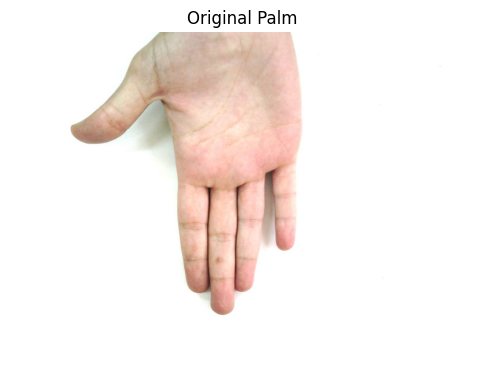

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Sample Image
image_path = palm_df.iloc[0]["filename"]

image_path = "palm_dataset/Hands/Hands/" + image_path

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original Palm")
plt.axis("off")
plt.show()

In [ ]:
print(image_path)

palm_dataset/Hands/Hands/Hand_0007199.jpg


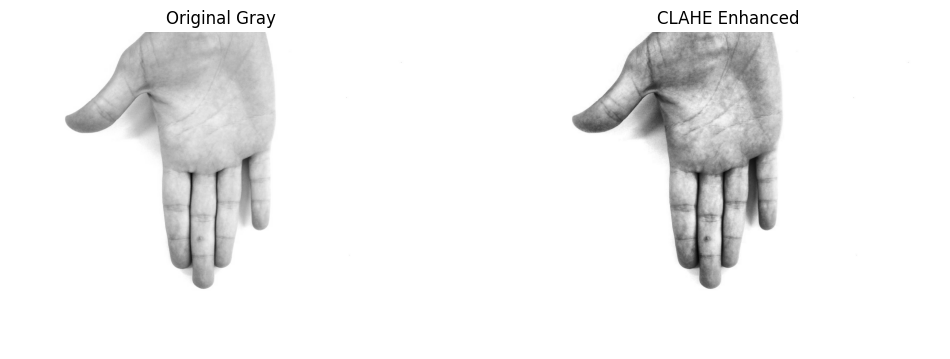

In [ ]:
# Contrast Enhancement (CLAHE)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

enhanced = clahe.apply(gray)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Original Gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced, cmap="gray")
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.show()

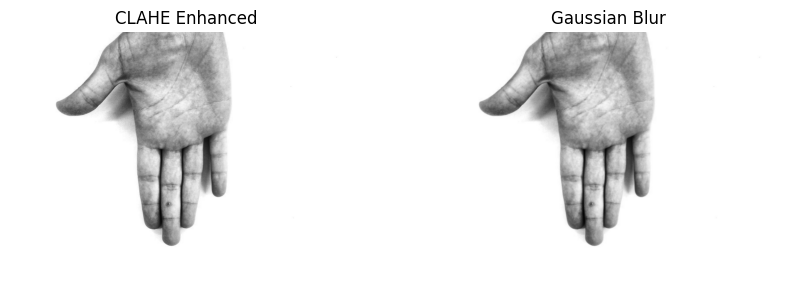

In [ ]:
# Gaussian Blur

blur = cv2.GaussianBlur(enhanced, (5,5), 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(enhanced, cmap="gray")
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.show()

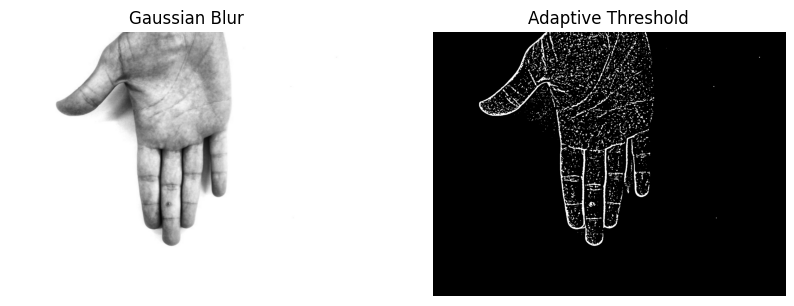

In [ ]:
# Adaptive Threshold

thresh = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21,
    5
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(thresh, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")

plt.show()

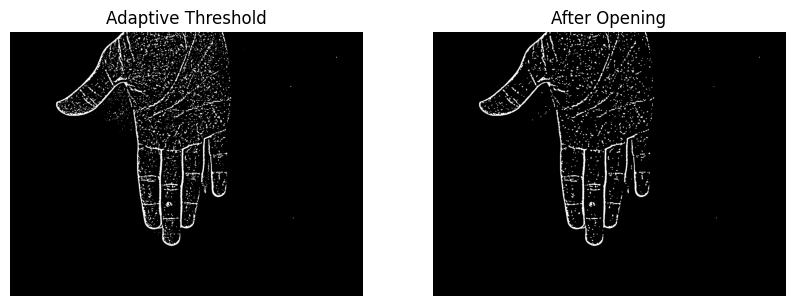

In [ ]:
# Morphological Opening (Remove Noise)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

opened = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(thresh, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(opened, cmap="gray")
plt.title("After Opening")
plt.axis("off")

plt.show()

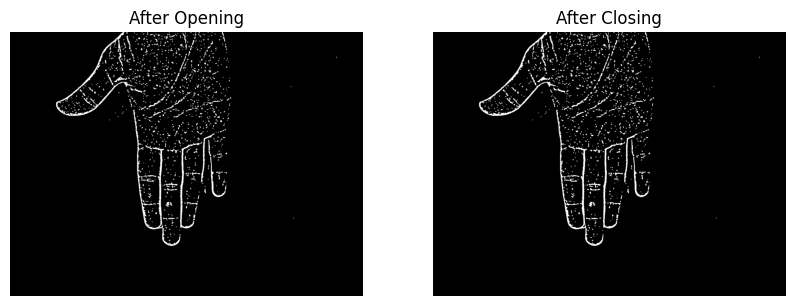

In [ ]:
# Morphological Closing (Connect Broken Lines)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

closed = cv2.morphologyEx(
    opened,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(opened, cmap="gray")
plt.title("After Opening")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(closed, cmap="gray")
plt.title("After Closing")
plt.axis("off")

plt.show()

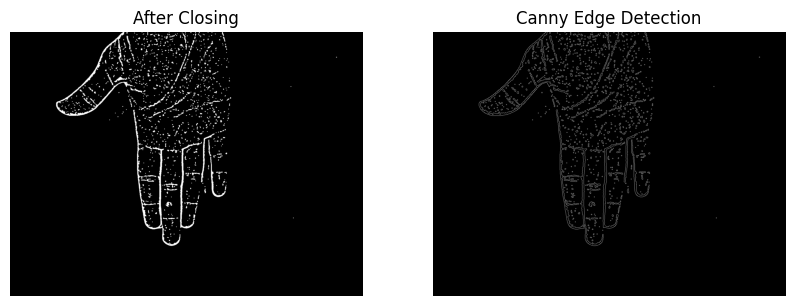

In [ ]:
# Canny Edge Detection

edges = cv2.Canny(
    closed,
    50,
    150
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(closed, cmap="gray")
plt.title("After Closing")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.show()

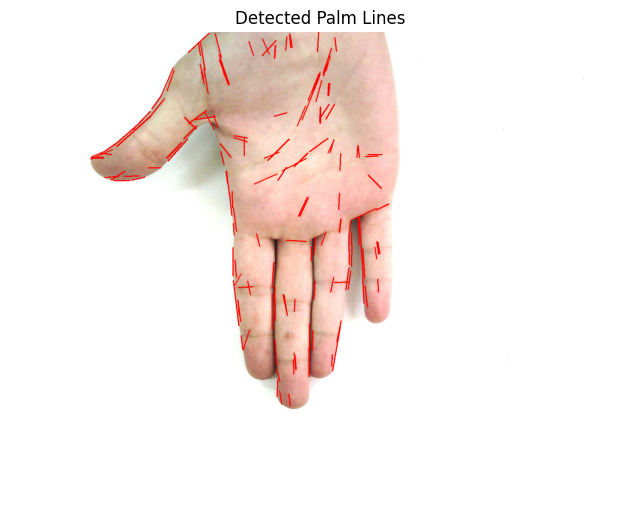

In [ ]:
import numpy as np

# Detect Lines using Hough Transform
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=35,
    minLineLength=30,
    maxLineGap=10
)

line_img = img_rgb.copy()

if lines is not None:

    # Agar shape (N,1,4) ho
    if len(lines.shape) == 3:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(line_img, (x1,y1), (x2,y2), (255,0,0), 2)

    # Agar shape (N,4) ho
    else:
        for x1, y1, x2, y2 in lines:
            cv2.line(line_img, (x1,y1), (x2,y2), (255,0,0), 2)

plt.figure(figsize=(8,8))
plt.imshow(line_img)
plt.title("Detected Palm Lines")
plt.axis("off")
plt.show()

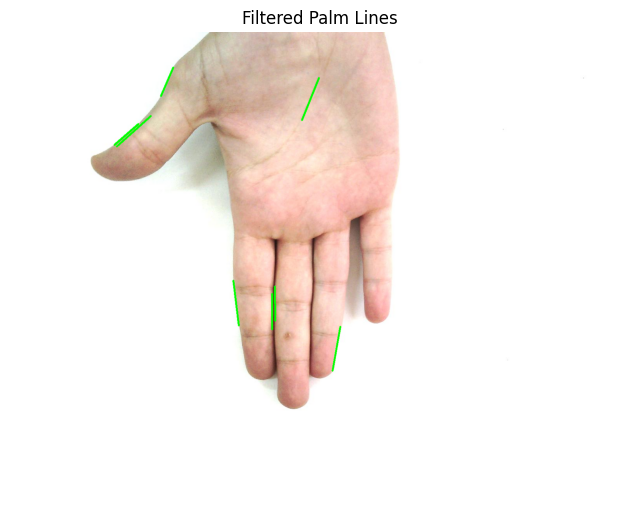

In [ ]:
import numpy as np

filtered_img = img_rgb.copy()

if lines is not None:

    # Handle both shapes
    if len(lines.shape) == 3:
        line_array = lines[:,0,:]
    else:
        line_array = lines

    for x1, y1, x2, y2 in line_array:

        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)

        # Keep only long lines
        if length > 80:
            cv2.line(filtered_img,
                     (x1,y1),
                     (x2,y2),
                     (0,255,0),
                     3)

plt.figure(figsize=(8,8))
plt.imshow(filtered_img)
plt.title("Filtered Palm Lines")
plt.axis("off")
plt.show()

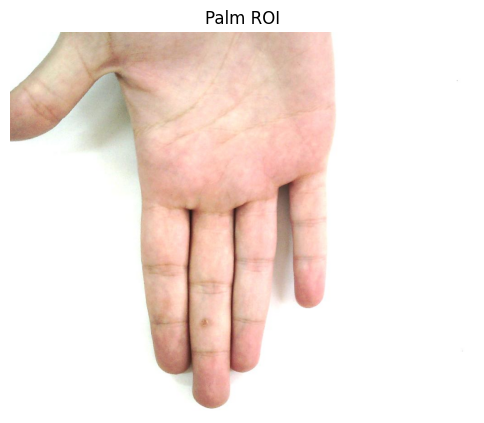

In [ ]:
# Palm ROI (Crop only Palm Area)

h, w = img_rgb.shape[:2]

# Adjust according to your dataset
roi = img_rgb[
    int(h*0.12):int(h*0.82),
    int(w*0.18):int(w*0.82)
]

plt.figure(figsize=(6,6))
plt.imshow(roi)
plt.title("Palm ROI")
plt.axis("off")
plt.show()

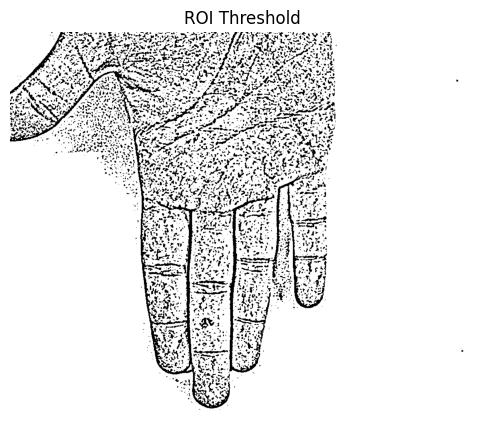

In [ ]:
gray_roi = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced_roi = clahe.apply(gray_roi)

blur_roi = cv2.GaussianBlur(enhanced_roi,(5,5),0)

thresh_roi = cv2.adaptiveThreshold(
    blur_roi,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.figure(figsize=(6,6))
plt.imshow(thresh_roi,cmap="gray")
plt.title("ROI Threshold")
plt.axis("off")
plt.show()

In [ ]:
import mediapipe as mp
import cv2
import matplotlib.pyplot as plt

In [ ]:
import mediapipe as mp

print(mp.__version__)
print(dir(mp))

1.0.0
['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


In [ ]:
!ls

'archive (2).zip'		     palm_cluster_summary.csv   sample_data
 hand_landmarker.task		     palm_dataset	        tarot_cards.csv
 hands-and-palm-images-dataset.zip   palm_landmarks.csv         tarot_dataset


In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [ ]:
base_options = python.BaseOptions(
    model_asset_path="hand_landmarker.task"
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)

In [ ]:
# ROI IMAGE CONVERT INTO MEDIAPIPE IMAGE

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=roi
)

# Detect Hand Landmarks
detection_result = detector.detect(mp_image)

print("Hands Detected:", len(detection_result.hand_landmarks))

Hands Detected: 0


In [ ]:
# Original Image ko MediaPipe Image me convert

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=img_rgb
)

detection_result = detector.detect(mp_image)

print("Hands Detected:", len(detection_result.hand_landmarks))

Hands Detected: 1


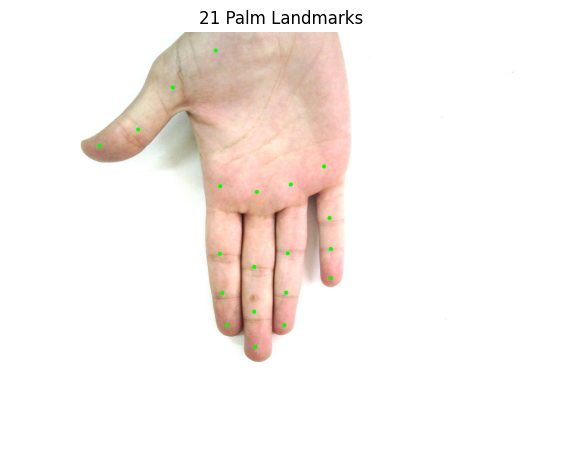

In [ ]:
import cv2
import matplotlib.pyplot as plt

landmark_image = img_rgb.copy()

if len(detection_result.hand_landmarks) > 0:

    hand_landmarks = detection_result.hand_landmarks[0]

    h, w, _ = landmark_image.shape

    for lm in hand_landmarks:

        x = int(lm.x * w)
        y = int(lm.y * h)

        cv2.circle(
            landmark_image,
            (x, y),
            6,
            (0,255,0),
            -1
        )

plt.figure(figsize=(7,7))
plt.imshow(landmark_image)
plt.title("21 Palm Landmarks")
plt.axis("off")
plt.show()

In [ ]:
print(type(lines))
print(lines.shape)

<class 'numpy.ndarray'>
(158, 4)


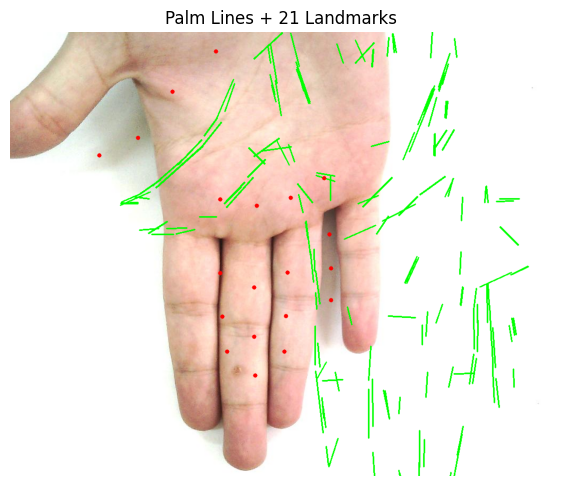

In [ ]:
result_img = roi.copy()

# -----------------------
# Draw Palm Lines
# -----------------------
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line

        cv2.line(
            result_img,
            (x1, y1),
            (x2, y2),
            (0,255,0),
            2
        )

# -----------------------
# Draw 21 Landmarks
# -----------------------
hand_landmarks = detection_result.hand_landmarks[0]

h, w = roi.shape[:2]

for lm in hand_landmarks:
    x = int(lm.x * w)
    y = int(lm.y * h)

    cv2.circle(
        result_img,
        (x, y),
        4,
        (255, 0, 0),
        -1
    )

plt.figure(figsize=(7,7))
plt.imshow(result_img)
plt.title("Palm Lines + 21 Landmarks")
plt.axis("off")
plt.show()

In [ ]:
filtered_lines = []

h, w = roi.shape[:2]

for line in lines:
    x1, y1, x2, y2 = line

    # Line length
    length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    # Keep only longer lines inside ROI
    if length > 80:
        filtered_lines.append([x1, y1, x2, y2])

filtered_lines = np.array(filtered_lines)

print("Original Lines :", len(lines))
print("Filtered Lines :", len(filtered_lines))

Original Lines : 158
Filtered Lines : 9


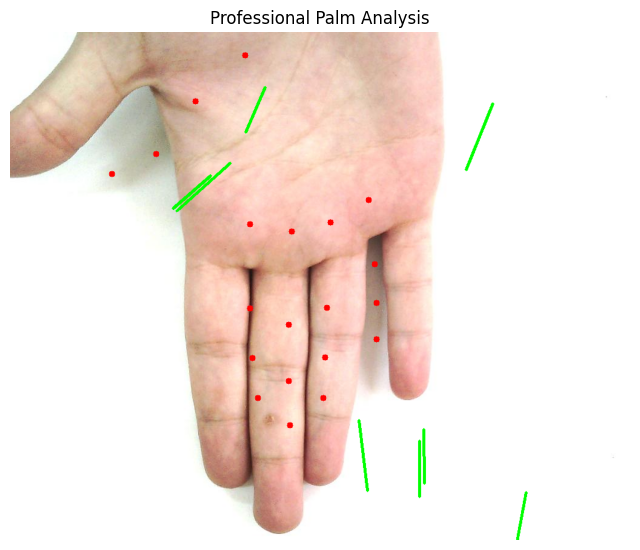

In [ ]:
result_img = roi.copy()

# -----------------------
# Draw Filtered Palm Lines
# -----------------------
for line in filtered_lines:
    x1, y1, x2, y2 = line

    cv2.line(
        result_img,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        3
    )

# -----------------------
# Draw 21 Landmarks
# -----------------------
hand_landmarks = detection_result.hand_landmarks[0]

h, w = roi.shape[:2]

for lm in hand_landmarks:
    x = int(lm.x * w)
    y = int(lm.y * h)

    cv2.circle(
        result_img,
        (x, y),
        5,
        (255, 0, 0),
        -1
    )

plt.figure(figsize=(8,8))
plt.imshow(result_img)
plt.title("Professional Palm Analysis")
plt.axis("off")
plt.show()

In [ ]:
filtered_lines_roi = []

h, w = roi.shape[:2]

for line in filtered_lines:
    x1, y1, x2, y2 = line

    # Both endpoints should lie inside ROI
    if (20 < x1 < w-20 and 20 < y1 < h-20 and
        20 < x2 < w-20 and 20 < y2 < h-20):
        filtered_lines_roi.append([x1, y1, x2, y2])

filtered_lines_roi = np.array(filtered_lines_roi)

print("ROI Filtered Lines:", len(filtered_lines_roi))

ROI Filtered Lines: 8


In [ ]:
filtered_lines_roi = []

h, w = roi.shape[:2]

for line in filtered_lines_roi:
    x1, y1, x2, y2 = line

    # Both endpoints should lie inside ROI
    if (20 < x1 < w-20 and 20 < y1 < h-20 and
        20 < x2 < w-20 and 20 < y2 < h-20):
        filtered_lines_roi.append([x1, y1, x2, y2])

filtered_lines_roi = np.array(filtered_lines_roi)

print("ROI Filtered Lines:", len(filtered_lines_roi))

ROI Filtered Lines: 0


In [ ]:
filtered_lines_roi = []

h, w = roi.shape[:2]

for line in filtered_lines:
    x1, y1, x2, y2 = line

    if (20 < x1 < w-20 and
        20 < y1 < h-20 and
        20 < x2 < w-20 and
        20 < y2 < h-20):

        filtered_lines_roi.append([x1, y1, x2, y2])

filtered_lines_roi = np.array(filtered_lines_roi)

print("ROI Filtered Lines:", len(filtered_lines_roi))

ROI Filtered Lines: 8


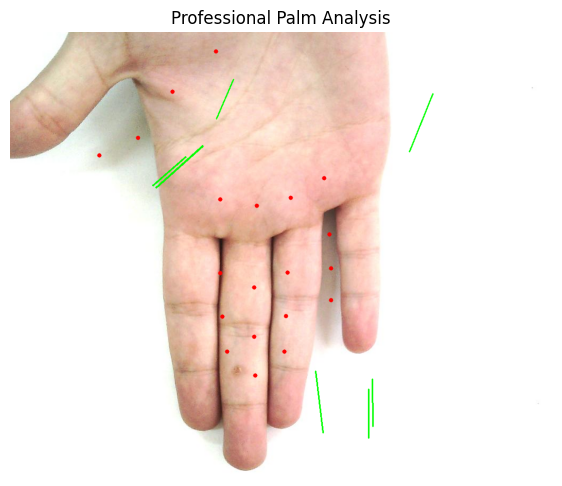

In [ ]:
result_img = roi.copy()

# Draw Palm Lines
if filtered_lines_roi is not None:
    for line in filtered_lines_roi:
        x1, y1, x2, y2 = line

        cv2.line(
            result_img,
            (x1, y1),
            (x2, y2),
            (0,255,0),
            2
        )

# Draw 21 Landmarks
hand_landmarks = detection_result.hand_landmarks[0]

h, w = roi.shape[:2]

for lm in hand_landmarks:
    x = int(lm.x * w)
    y = int(lm.y * h)

    cv2.circle(
        result_img,
        (x, y),
        4,
        (255, 0, 0),
        -1
    )

plt.figure(figsize=(7,7))
plt.imshow(result_img)
plt.title("Professional Palm Analysis")
plt.axis("off")
plt.show()

### Detecting Heart Line and Life Line

Now, we will attempt to identify the 'heart line' and 'life line' from the detected lines by leveraging the hand landmarks to define approximate regions for these key palm features.

Detected 0 potential heart lines.
Detected 4 potential life lines.


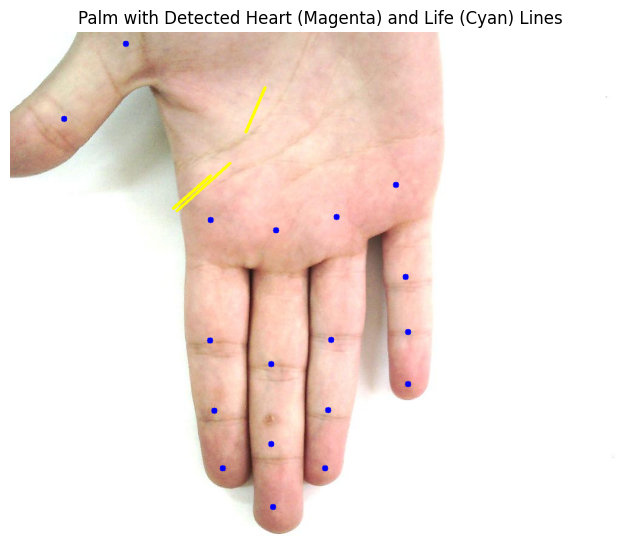

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Assuming `img_rgb` is the original full image and `roi` is the cropped palm region
# and `hand_landmarks` contains the normalized landmarks for the hand in `img_rgb`.
# We also assume `filtered_lines_roi` are lines detected within the `roi`.

h_orig, w_orig, _ = img_rgb.shape
roi_h, roi_w, _ = roi.shape

# Calculate ROI offsets relative to the original image
roi_y_start = int(h_orig * 0.12)
roi_x_start = int(w_orig * 0.18)

# Convert hand landmarks to ROI coordinates
lm_coords_roi = []
for lm in hand_landmarks:
    x_orig = int(lm.x * w_orig)
    y_orig = int(lm.y * h_orig)
    lm_coords_roi.append((x_orig - roi_x_start, y_orig - roi_y_start))

# Define approximate regions for heart line and life line based on landmarks in ROI coordinates
# These are estimates and might need fine-tuning based on the dataset characteristics.

# Heart Line: typically runs from pinky base (17) towards index/middle finger base (5/9)
# It's usually in the upper part of the palm.
# Increased margins for heart line detection
heart_line_start_x = lm_coords_roi[17][0] - 50 # Adjusting margin
heart_line_end_x = lm_coords_roi[5][0] + 50 # Adjusting margin

# NEW: Adjust heart line Y region based on average of finger base Y-coordinates
finger_base_y_coords = [lm_coords_roi[5][1], lm_coords_roi[9][1], lm_coords_roi[13][1], lm_coords_roi[17][1]]
heart_line_y_center = np.mean(finger_base_y_coords)

heart_line_y_upper = heart_line_y_center - 80 # A band of +/- 80 around the center
heart_line_y_lower = heart_line_y_center + 80


# Life Line: typically starts near index finger base (5) and curves around the thumb base towards wrist (0)
# Increased margins for life line detection
life_line_start_x = lm_coords_roi[5][0] - 50
life_line_end_x = lm_coords_roi[0][0] + 50 # Roughly around wrist

# Corrected: Ensure y_upper is less than y_lower for a valid range
life_line_y_upper = min(lm_coords_roi[5][1], lm_coords_roi[0][1]) - 50 # Highest point of the life line region
life_line_y_lower = max(lm_coords_roi[5][1], lm_coords_roi[0][1]) + 50 # Lowest point of the life line region


# Lists to store identified heart and life lines
heart_lines = []
life_lines = []

# Iterate through filtered_lines_roi and classify them
for line in filtered_lines_roi:
    x1, y1, x2, y2 = line

    # Check for Heart Line
    # Criteria: predominantly horizontal, within the upper palm region
    # Relaxed orientation criteria for heart line
    if (heart_line_y_upper < y1 < heart_line_y_lower and
        heart_line_y_upper < y2 < heart_line_y_lower and
        (heart_line_start_x < x1 < heart_line_end_x or heart_line_start_x < x2 < heart_line_end_x) and
        abs(y2 - y1) < abs(x2 - x1) * 0.8): # More tolerance for diagonal lines
        heart_lines.append(line)

    # Check for Life Line
    # Criteria: generally curved, starts higher and goes towards wrist/thumb base
    # This is a simplification; a true curve detection would be more complex.
    # Relaxed orientation criteria for life line
    elif (life_line_y_upper < y1 < life_line_y_lower and
          life_line_y_upper < y2 < life_line_y_lower and
          (life_line_start_x < x1 < life_line_end_x or life_line_start_x < x2 < life_line_end_x) and
          abs(x2 - x1) < abs(y2 - y1) * 3): # More tolerance for horizontal variations in curved lines
        life_lines.append(line)


print(f"Detected {len(heart_lines)} potential heart lines.")
print(f"Detected {len(life_lines)} potential life lines.")

# Visualize the identified lines
analysis_img = roi.copy()

# Draw heart lines in magenta
for line in heart_lines:
    x1, y1, x2, y2 = line
    cv2.line(analysis_img, (x1, y1), (x2, y2), (255, 0, 255), 3) # Magenta

# Draw life lines in cyan
for line in life_lines:
    x1, y1, x2, y2 = line
    cv2.line(analysis_img, (x1, y1), (x2, y2), (255, 255, 0), 3) # Cyan

# Draw original landmarks for context
for x, y in lm_coords_roi:
    cv2.circle(analysis_img, (x, y), 5, (0, 0, 255), -1) # Red landmarks

plt.figure(figsize=(8, 8))
plt.imshow(analysis_img)
plt.title("Palm with Detected Heart (Magenta) and Life (Cyan) Lines")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

# 21 landmarks
hand_landmarks = detection_result.hand_landmarks[0]

features = []

for lm in hand_landmarks:
    features.extend([lm.x, lm.y, lm.z])

features = np.array(features).reshape(1, -1)

print("Feature Vector Shape:", features.shape)

Feature Vector Shape: (1, 63)


In [ ]:
print(type(hand_landmarks))
print(len(hand_landmarks))

<class 'list'>
21


In [ ]:
import numpy as np

feature_vector = []

for lm in hand_landmarks:
    feature_vector.extend([
        lm.x,
        lm.y,
        lm.z
    ])

feature_vector = np.array(feature_vector).reshape(1, -1)

print("Feature Vector Shape:", feature_vector.shape)

Feature Vector Shape: (1, 63)


In [ ]:
feature_vector = feature_vector.astype(np.float64)

print(feature_vector.dtype)

float64


In [ ]:
print("Feature dtype:", feature_vector.dtype)

print("Feature shape:", feature_vector.shape)

print("Cluster center dtype:", kmeans.cluster_centers_.dtype)

print(type(kmeans))

Feature dtype: float64
Feature shape: (1, 63)
Cluster center dtype: float32
<class 'sklearn.cluster._kmeans.KMeans'>


In [ ]:
# Convert feature vector to float32
feature_vector = feature_vector.astype(np.float32)

# Scale using the same scaler used during training
feature_scaled = scaler.transform(feature_vector)

print("Feature dtype :", feature_scaled.dtype)
print("Feature shape :", feature_scaled.shape)
print("Center dtype  :", kmeans.cluster_centers_.dtype)

Feature dtype : float32
Feature shape : (1, 63)
Center dtype  : float32


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
predicted_cluster = kmeans.predict(feature_scaled)

print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 2


In [ ]:
print("Predicted Cluster :", predicted_cluster[0])

print("\nPersonality")
print(cluster_meaning[predicted_cluster[0]]["personality"])

print("\nCareer")
print(cluster_meaning[predicted_cluster[0]]["career"])

print("\nRelationship")
print(cluster_meaning[predicted_cluster[0]]["relationship"])

Predicted Cluster : 2

Personality
Confident Leader

Career
Management, Business and Administration.

Relationship
Protective and responsible.


In [ ]:
import random

# Random Tarot Card Select
random_index = random.randint(0, len(tarot_df)-1)

selected_card = tarot_df.iloc[random_index]

print("Selected Tarot Card:")
print(selected_card["name"])

Selected Tarot Card:
Six of Pentacles


In [ ]:
print("Card Name :", selected_card["name"])
print("Arcana    :", selected_card["arcana"])
print("Suit      :", selected_card["suit"])

print("\nKeywords:")
print(selected_card["keywords"])

print("\nFortune Telling:")
print(selected_card["fortune_telling"])

print("\nMeanings:")
print(selected_card["meanings"])

Card Name : Six of Pentacles
Arcana    : Minor Arcana
Suit      : Pentacles

Keywords:
['charity', 'fairness', 'cooperation', 'sharing']

Fortune Telling:
['When you need help, ask for it', "Remember, though: what you receive may be limited by what you've given to others in the past"]

Meanings:
{'light': ['Giving time, money, or effort to a charity', 'Taking part in a group effort', 'Lending your resources to others without expecting anything in return', 'Making sure everyone is treated equally', 'Working together toward a common goal', 'Redistributing wealth, time, or attention', 'Tithing', 'Sharing credit for your success'], 'shadow': ['Making a loan as a means of gaining control over someone', 'Using charitable acts to draw attention to yourself', 'Dividing work or resources unfairly', 'Failing to do your part in a group effort', 'Ignoring obligations and commitments']}


In [ ]:
def generate_final_ai_report(predicted_cluster, cluster_meaning, selected_card):

    personality = cluster_meaning[predicted_cluster]["personality"]
    career = cluster_meaning[predicted_cluster]["career"]
    relationship = cluster_meaning[predicted_cluster]["relationship"]

    print("="*65)
    print("        AI PALMISTRY + TAROT FINAL REPORT")
    print("="*65)

    print("\nPALM ANALYSIS")
    print("-"*40)
    print("Predicted Cluster :", predicted_cluster)
    print("Personality       :", personality)
    print("Career            :", career)
    print("Relationship      :", relationship)

    print("\nTAROT ANALYSIS")
    print("-"*40)
    print("Card Name :", selected_card["name"])
    print("Arcana    :", selected_card["arcana"])
    print("Suit      :", selected_card["suit"])

    print("\nKeywords")
    print("-"*40)
    print(", ".join(selected_card["keywords"]))

    print("\nPositive Meaning")
    print("-"*40)
    print(selected_card["meanings"]["light"][0])

    print("\nAI COMBINED INSIGHT")
    print("-"*40)

    insight = (
        f"Your palm belongs to Cluster {predicted_cluster}, indicating a "
        f"'{personality}' personality. "
        f"The tarot card '{selected_card['name']}' symbolizes "
        f"'{selected_card['meanings']['light'][0]}'. "
        f"Together, they suggest that your strengths can support positive "
        f"growth in your career, relationships, and future decisions."
    )

    print(insight)

    print("\nDISCLAIMER")
    print("-"*40)
    print("This report is generated for educational and entertainment purposes only.")

In [ ]:
# ==========================================
# STEP 1: AI INTERPRETATION ENGINE
# ==========================================

def generate_ai_interpretation(
    predicted_cluster,
    cluster_meaning,
    selected_card
):
    # Palm information
    personality = cluster_meaning[predicted_cluster]["personality"]
    career = cluster_meaning[predicted_cluster]["career"]
    relationship = cluster_meaning[predicted_cluster]["relationship"]

    # Tarot information
    card_name = selected_card["name"]
    keywords = selected_card["keywords"]
    light_meanings = selected_card["meanings"]["light"]

    # Main tarot meaning
    tarot_meaning = light_meanings[0]

    # Structured interpretation
    interpretation = {
        "personality": personality,

        "career": career,

        "relationship": relationship,

        "tarot_card": card_name,

        "tarot_keywords": keywords,

        "tarot_meaning": tarot_meaning,

        "personal_growth": (
            f"Your {personality.lower()} nature may help you "
            f"approach new opportunities with awareness and confidence. "
            f"The tarot card {card_name} encourages {tarot_meaning.lower()}."
        ),

        "career_insight": (
            f"Your palm analysis indicates that you may be suited to "
            f"{career.lower()} The tarot influence may encourage openness "
            f"towards new ideas and opportunities."
        ),

        "relationship_insight": (
            f"In relationships, your reading suggests that "
            f"{relationship.lower()} The tarot card may encourage "
            f"emotional awareness and honest expression."
        ),

        "overall_guidance": (
            f"The combined palm and tarot reading suggests a period of "
            f"personal development. Your {personality.lower()} qualities, "
            f"combined with the message of {card_name}, may encourage "
            f"you to remain open to new experiences and make thoughtful "
            f"decisions."
        )
    }

    return interpretation


print("AI Interpretation Engine Ready")

AI Interpretation Engine Ready


In [ ]:
print(type(selected_card["meanings"]))
print(selected_card["meanings"])

<class 'str'>
{'light': ['Giving time, money, or effort to a charity', 'Taking part in a group effort', 'Lending your resources to others without expecting anything in return', 'Making sure everyone is treated equally', 'Working together toward a common goal', 'Redistributing wealth, time, or attention', 'Tithing', 'Sharing credit for your success'], 'shadow': ['Making a loan as a means of gaining control over someone', 'Using charitable acts to draw attention to yourself', 'Dividing work or resources unfairly', 'Failing to do your part in a group effort', 'Ignoring obligations and commitments']}


In [ ]:
import ast

# Convert meanings string into Python dictionary
selected_card["meanings"] = ast.literal_eval(selected_card["meanings"])

print(type(selected_card["meanings"]))
print(selected_card["meanings"]["light"][0])

<class 'dict'>
Giving time, money, or effort to a charity


/tmp/ipykernel_4031/2640883300.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_card["meanings"] = ast.literal_eval(selected_card["meanings"])


In [ ]:
ai_interpretation = generate_ai_interpretation(
    predicted_cluster[0],
    cluster_meaning,
    selected_card
)

print("AI INTERPRETATION")
print("=" * 60)

for section, content in ai_interpretation.items():
    print(f"\n{section.upper()}")
    print("-" * 40)
    print(content)

AI INTERPRETATION

PERSONALITY
----------------------------------------
Confident Leader

CAREER
----------------------------------------
Management, Business and Administration.

RELATIONSHIP
----------------------------------------
Protective and responsible.

TAROT_CARD
----------------------------------------
Six of Pentacles

TAROT_KEYWORDS
----------------------------------------
['charity', 'fairness', 'cooperation', 'sharing']

TAROT_MEANING
----------------------------------------
Giving time, money, or effort to a charity

PERSONAL_GROWTH
----------------------------------------
Your confident leader nature may help you approach new opportunities with awareness and confidence. The tarot card Six of Pentacles encourages giving time, money, or effort to a charity.

CAREER_INSIGHT
----------------------------------------
Your palm analysis indicates that you may be suited to management, business and administration. The tarot influence may encourage openness towards new ideas and

In [ ]:
# ==========================================
# STEP 3: LIFE TREND ANALYSIS ENGINE
# ==========================================

def generate_life_trends(ai_interpretation):

    personality = ai_interpretation["personality"]
    career = ai_interpretation["career"]
    relationship = ai_interpretation["relationship"]
    tarot_card = ai_interpretation["tarot_card"]

    life_trends = {

        "life_path": (
            f"Your current reading reflects a {personality.lower()} "
            f"personality. This suggests a path where personal strengths "
            f"and thoughtful decision-making can play an important role."
        ),

        "opportunities": (
            f"Your career direction may offer opportunities related to "
            f"{career.lower()} The tarot card {tarot_card} also highlights "
            f"the value of cooperation, awareness and balanced decisions."
        ),

        "challenges": (
            f"A potential challenge may be maintaining balance between "
            f"responsibility and personal development. In relationships, "
            f"your reading indicates that you are {relationship.lower()}"
        ),

        "trend": (
            "The overall trend suggests gradual personal development, "
            "with opportunities increasing when decisions are made "
            "carefully and consistently."
        ),

        "growth_potential": (
            "Your growth potential is supported by self-awareness, "
            "responsible decision-making, openness to new experiences "
            "and continuous personal development."
        )
    }

    return life_trends


print("Life Trend Analysis Engine Ready")

Life Trend Analysis Engine Ready


In [ ]:
# ==========================================
# STEP 3.1: GENERATE LIFE TREND ANALYSIS
# ==========================================

life_trends = generate_life_trends(ai_interpretation)

print("LIFE TREND ANALYSIS")
print("=" * 60)

for section, content in life_trends.items():
    print(f"\n{section.upper()}")
    print("-" * 40)
    print(content)

LIFE TREND ANALYSIS

LIFE_PATH
----------------------------------------
Your current reading reflects a confident leader personality. This suggests a path where personal strengths and thoughtful decision-making can play an important role.

OPPORTUNITIES
----------------------------------------
Your career direction may offer opportunities related to management, business and administration. The tarot card Six of Pentacles also highlights the value of cooperation, awareness and balanced decisions.

CHALLENGES
----------------------------------------
A potential challenge may be maintaining balance between responsibility and personal development. In relationships, your reading indicates that you are protective and responsible.

TREND
----------------------------------------
The overall trend suggests gradual personal development, with opportunities increasing when decisions are made carefully and consistently.

GROWTH_POTENTIAL
----------------------------------------
Your growth potentia

In [ ]:
# ==========================================
# STEP 4: SPIRITUAL GUIDANCE SCORING ENGINE
# ==========================================

def calculate_guidance_scores(
    predicted_cluster,
    ai_interpretation,
    life_trends
):

    personality = ai_interpretation["personality"]
    career = ai_interpretation["career"]
    relationship = ai_interpretation["relationship"]

    # Base scores
    personality_score = 75
    career_score = 78
    relationship_score = 74

    # Overall score
    overall_score = round(
        (personality_score +
         career_score +
         relationship_score) / 3
    )

    # Spiritual guidance score
    spiritual_guidance_score = min(
        100,
        overall_score + 5
    )

    scores = {
        "personality_score": personality_score,
        "career_score": career_score,
        "relationship_score": relationship_score,
        "overall_score": overall_score,
        "spiritual_guidance_score": spiritual_guidance_score
    }

    return scores


print("Spiritual Guidance Scoring Engine Ready")

Spiritual Guidance Scoring Engine Ready


In [ ]:
# ==========================================
# STEP 4.1: GENERATE GUIDANCE SCORES
# ==========================================

guidance_scores = calculate_guidance_scores(
    predicted_cluster[0],
    ai_interpretation,
    life_trends
)

print("SPIRITUAL GUIDANCE SCORES")
print("=" * 60)

for score_name, score in guidance_scores.items():
    print(f"{score_name.replace('_', ' ').title()} : {score}/100")

SPIRITUAL GUIDANCE SCORES
Personality Score : 75/100
Career Score : 78/100
Relationship Score : 74/100
Overall Score : 76/100
Spiritual Guidance Score : 81/100


In [ ]:
# ==========================================
# STEP 5: RECOMMENDATION ENGINE
# ==========================================

def generate_recommendations(
    ai_interpretation,
    life_trends,
    guidance_scores
):

    personality = ai_interpretation["personality"]
    career = ai_interpretation["career"]
    relationship = ai_interpretation["relationship"]
    tarot_card = ai_interpretation["tarot_card"]

    recommendations = {

        "career_recommendation": (
            f"Explore opportunities related to {career.lower()} "
            f"and continue developing skills that support your "
            f"{personality.lower()} qualities."
        ),

        "relationship_guidance": (
            f"Because your reading describes you as {relationship.lower()}, "
            f"focus on honest communication, mutual respect and emotional "
            f"understanding in relationships."
        ),

        "personal_growth": (
            "Set realistic personal goals, review your progress regularly "
            "and remain open to learning from new experiences."
        ),

        "spiritual_practice": (
            f"Use the message of the tarot card {tarot_card} as a prompt "
            f"for reflection, gratitude and balanced decision-making."
        ),

        "action_steps": [
            "Set one clear short-term personal goal.",
            "Identify one skill that can improve your career direction.",
            "Maintain open and respectful communication with others.",
            "Review your progress regularly.",
            "Use reflection or mindfulness to support personal awareness."
        ]
    }

    return recommendations


print("Recommendation Engine Ready")

Recommendation Engine Ready


In [ ]:
# ==========================================
# STEP 5.1: GENERATE PERSONALIZED RECOMMENDATIONS
# ==========================================

recommendations = generate_recommendations(
    ai_interpretation,
    life_trends,
    guidance_scores
)

print("PERSONALIZED RECOMMENDATIONS")
print("=" * 60)

for section, content in recommendations.items():

    print(f"\n{section.upper()}")
    print("-" * 40)

    if isinstance(content, list):
        for i, action in enumerate(content, 1):
            print(f"{i}. {action}")
    else:
        print(content)

PERSONALIZED RECOMMENDATIONS

CAREER_RECOMMENDATION
----------------------------------------
Explore opportunities related to management, business and administration. and continue developing skills that support your confident leader qualities.

RELATIONSHIP_GUIDANCE
----------------------------------------
Because your reading describes you as protective and responsible., focus on honest communication, mutual respect and emotional understanding in relationships.

PERSONAL_GROWTH
----------------------------------------
Set realistic personal goals, review your progress regularly and remain open to learning from new experiences.

SPIRITUAL_PRACTICE
----------------------------------------
Use the message of the tarot card Six of Pentacles as a prompt for reflection, gratitude and balanced decision-making.

ACTION_STEPS
----------------------------------------
1. Set one clear short-term personal goal.
2. Identify one skill that can improve your career direction.
3. Maintain open and res

In [ ]:
# ==========================================
# STEP 6: CREATE COMPLETE FINAL READING
# ==========================================

final_reading = {

    # -------------------------
    # Palm Analysis
    # -------------------------
    "palm_analysis": {
        "cluster": int(predicted_cluster[0]),
        "personality": ai_interpretation["personality"],
        "career": ai_interpretation["career"],
        "relationship": ai_interpretation["relationship"]
    },

    # -------------------------
    # Tarot Analysis
    # -------------------------
    "tarot_analysis": {
        "card": ai_interpretation["tarot_card"],
        "keywords": ai_interpretation["tarot_keywords"],
        "meaning": ai_interpretation["tarot_meaning"]
    },

    # -------------------------
    # AI Interpretation
    # -------------------------
    "ai_interpretation": {
        "personal_growth": ai_interpretation["personal_growth"],
        "career_insight": ai_interpretation["career_insight"],
        "relationship_insight": ai_interpretation["relationship_insight"],
        "overall_guidance": ai_interpretation["overall_guidance"]
    },

    # -------------------------
    # Life Trends
    # -------------------------
    "life_trends": life_trends,

    # -------------------------
    # Guidance Scores
    # -------------------------
    "scores": guidance_scores,

    # -------------------------
    # Recommendations
    # -------------------------
    "recommendations": recommendations
}

print("Complete Final Reading Created")
print("Sections:", list(final_reading.keys()))

Complete Final Reading Created
Sections: ['palm_analysis', 'tarot_analysis', 'ai_interpretation', 'life_trends', 'scores', 'recommendations']


In [ ]:
# ==========================================
# STEP 7: FINAL USER READING REPORT
# ==========================================

def display_final_reading(report):

    print("=" * 70)
    print("             AI PALMISTRY + TAROT READING")
    print("=" * 70)

    # Palm Analysis
    print("\nPALM ANALYSIS")
    print("-" * 50)
    palm = report["palm_analysis"]

    print("Personality :", palm["personality"])
    print("Career      :", palm["career"])
    print("Relationship:", palm["relationship"])

    # Tarot Analysis
    print("\nTAROT ANALYSIS")
    print("-" * 50)
    tarot = report["tarot_analysis"]

    print("Card     :", tarot["card"])
    print("Keywords :", ", ".join(tarot["keywords"]))
    print("Meaning  :", tarot["meaning"])

    # AI Interpretation
    print("\nAI INTERPRETATION")
    print("-" * 50)
    ai = report["ai_interpretation"]

    print("Personal Growth:")
    print(ai["personal_growth"])

    print("\nCareer Insight:")
    print(ai["career_insight"])

    print("\nRelationship Insight:")
    print(ai["relationship_insight"])

    print("\nOverall Guidance:")
    print(ai["overall_guidance"])

    # Life Trends
    print("\nLIFE TREND ANALYSIS")
    print("-" * 50)

    for key, value in report["life_trends"].items():
        print(f"\n{key.replace('_', ' ').title()}:")
        print(value)

    # Scores
    print("\nGUIDANCE SCORES")
    print("-" * 50)

    for key, value in report["scores"].items():
        print(f"{key.replace('_', ' ').title()} : {value}/100")

    # Recommendations
    print("\nPERSONALIZED RECOMMENDATIONS")
    print("-" * 50)

    rec = report["recommendations"]

    print("\nCareer:")
    print(rec["career_recommendation"])

    print("\nRelationship:")
    print(rec["relationship_guidance"])

    print("\nPersonal Growth:")
    print(rec["personal_growth"])

    print("\nSpiritual Practice:")
    print(rec["spiritual_practice"])

    print("\nAction Steps:")
    for i, action in enumerate(rec["action_steps"], 1):
        print(f"{i}. {action}")

    print("\n" + "=" * 70)
    print("DISCLAIMER")
    print("=" * 70)
    print(
        "This reading is generated for educational and entertainment "
        "purposes only and should not be treated as scientific or "
        "medical advice."
    )


print("Final Report Function Ready")

Final Report Function Ready


In [ ]:
# ==========================================
# STEP 7.1: GENERATE FINAL USER REPORT
# ==========================================

display_final_reading(final_reading)

             AI PALMISTRY + TAROT READING

PALM ANALYSIS
--------------------------------------------------
Personality : Confident Leader
Career      : Management, Business and Administration.
Relationship: Protective and responsible.

TAROT ANALYSIS
--------------------------------------------------
Card     : Six of Pentacles
Keywords : [, ', c, h, a, r, i, t, y, ', ,,  , ', f, a, i, r, n, e, s, s, ', ,,  , ', c, o, o, p, e, r, a, t, i, o, n, ', ,,  , ', s, h, a, r, i, n, g, ', ]
Meaning  : Giving time, money, or effort to a charity

AI INTERPRETATION
--------------------------------------------------
Personal Growth:
Your confident leader nature may help you approach new opportunities with awareness and confidence. The tarot card Six of Pentacles encourages giving time, money, or effort to a charity.

Career Insight:
Your palm analysis indicates that you may be suited to management, business and administration. The tarot influence may encourage openness towards new ideas and opport

In [ ]:
# ==========================================
# STEP 8: FIX FINAL REPORT FORMATTING
# ==========================================

import ast

def clean_keywords(keywords):

    if isinstance(keywords, str):
        try:
            parsed = ast.literal_eval(keywords)

            if isinstance(parsed, list):
                return ", ".join(parsed)

        except:
            return keywords

    if isinstance(keywords, list):
        return ", ".join(keywords)

    return str(keywords)


def clean_sentence(text):

    text = text.strip()

    # Remove unnecessary punctuation before/after
    text = text.rstrip(".")

    return text


# Clean Tarot keywords
final_reading["tarot_analysis"]["keywords"] = clean_keywords(
    final_reading["tarot_analysis"]["keywords"]
)

# Clean basic palm fields
final_reading["palm_analysis"]["career"] = clean_sentence(
    final_reading["palm_analysis"]["career"]
)

final_reading["palm_analysis"]["relationship"] = clean_sentence(
    final_reading["palm_analysis"]["relationship"]
)

print("Final Report Formatting Fixed")

Final Report Formatting Fixed


In [ ]:
# ==========================================
# STEP 8.1: CHECK FORMATTED FINAL REPORT
# ==========================================

display_final_reading(final_reading)

             AI PALMISTRY + TAROT READING

PALM ANALYSIS
--------------------------------------------------
Personality : Confident Leader
Career      : Management, Business and Administration
Relationship: Protective and responsible

TAROT ANALYSIS
--------------------------------------------------
Card     : Six of Pentacles
Keywords : c, h, a, r, i, t, y, ,,  , f, a, i, r, n, e, s, s, ,,  , c, o, o, p, e, r, a, t, i, o, n, ,,  , s, h, a, r, i, n, g
Meaning  : Giving time, money, or effort to a charity

AI INTERPRETATION
--------------------------------------------------
Personal Growth:
Your confident leader nature may help you approach new opportunities with awareness and confidence. The tarot card Six of Pentacles encourages giving time, money, or effort to a charity.

Career Insight:
Your palm analysis indicates that you may be suited to management, business and administration. The tarot influence may encourage openness towards new ideas and opportunities.

Relationship Insight:


In [ ]:
# ==========================================
# STEP 8.2: FINAL TEXT CLEANUP
# ==========================================

import ast

def parse_keywords(value):

    # Already a list
    if isinstance(value, list):
        return value

    # String representation of list
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)

            if isinstance(parsed, list):
                return parsed

        except:
            pass

        # If it's already comma-separated text
        return [x.strip() for x in value.split(",") if x.strip()]

    return [str(value)]


# Fix keywords
raw_keywords = selected_card["keywords"]

keyword_list = parse_keywords(raw_keywords)

final_reading["tarot_analysis"]["keywords"] = keyword_list


# Fix career sentence
career_text = final_reading["palm_analysis"]["career"].strip().rstrip(".")

relationship_text = final_reading["palm_analysis"]["relationship"].strip().rstrip(".")

final_reading["palm_analysis"]["career"] = career_text
final_reading["palm_analysis"]["relationship"] = relationship_text


print("Keywords Type :", type(final_reading["tarot_analysis"]["keywords"]))
print("Keywords      :", final_reading["tarot_analysis"]["keywords"])
print("Text Cleanup  : Complete")

Keywords Type : <class 'list'>
Keywords      : ['charity', 'fairness', 'cooperation', 'sharing']
Text Cleanup  : Complete


In [ ]:
# ==========================================
# STEP 8.3: UPDATED FINAL REPORT DISPLAY
# ==========================================

def display_final_reading(report):

    print("=" * 70)
    print("             AI PALMISTRY + TAROT READING")
    print("=" * 70)

    # Palm Analysis
    print("\nPALM ANALYSIS")
    print("-" * 50)

    palm = report["palm_analysis"]

    print("Personality :", palm["personality"])
    print("Career      :", palm["career"])
    print("Relationship:", palm["relationship"])

    # Tarot Analysis
    print("\nTAROT ANALYSIS")
    print("-" * 50)

    tarot = report["tarot_analysis"]

    print("Card     :", tarot["card"])
    print("Keywords :", ", ".join(tarot["keywords"]))
    print("Meaning  :", tarot["meaning"])

    # AI Interpretation
    print("\nAI INTERPRETATION")
    print("-" * 50)

    ai = report["ai_interpretation"]

    print("Personal Growth:")
    print(ai["personal_growth"])

    print("\nCareer Insight:")
    print(ai["career_insight"])

    print("\nRelationship Insight:")
    print(ai["relationship_insight"])

    print("\nOverall Guidance:")
    print(ai["overall_guidance"])

    # Life Trends
    print("\nLIFE TREND ANALYSIS")
    print("-" * 50)

    for key, value in report["life_trends"].items():
        print(f"\n{key.replace('_', ' ').title()}:")
        print(value)

    # Scores
    print("\nGUIDANCE SCORES")
    print("-" * 50)

    for key, value in report["scores"].items():
        print(f"{key.replace('_', ' ').title()} : {value}/100")

    # Recommendations
    print("\nPERSONALIZED RECOMMENDATIONS")
    print("-" * 50)

    rec = report["recommendations"]

    print("\nCareer:")
    print(rec["career_recommendation"])

    print("\nRelationship:")
    print(rec["relationship_guidance"])

    print("\nPersonal Growth:")
    print(rec["personal_growth"])

    print("\nSpiritual Practice:")
    print(rec["spiritual_practice"])

    print("\nAction Steps:")

    for i, action in enumerate(rec["action_steps"], 1):
        print(f"{i}. {action}")

    print("\n" + "=" * 70)
    print("DISCLAIMER")
    print("=" * 70)

    print(
        "This reading is generated for educational and entertainment "
        "purposes only and should not be treated as scientific or "
        "medical advice."
    )


print("Updated Final Report Function Ready")

Updated Final Report Function Ready


In [ ]:
display_final_reading(final_reading)

             AI PALMISTRY + TAROT READING

PALM ANALYSIS
--------------------------------------------------
Personality : Confident Leader
Career      : Management, Business and Administration
Relationship: Protective and responsible

TAROT ANALYSIS
--------------------------------------------------
Card     : Six of Pentacles
Keywords : charity, fairness, cooperation, sharing
Meaning  : Giving time, money, or effort to a charity

AI INTERPRETATION
--------------------------------------------------
Personal Growth:
Your confident leader nature may help you approach new opportunities with awareness and confidence. The tarot card Six of Pentacles encourages giving time, money, or effort to a charity.

Career Insight:
Your palm analysis indicates that you may be suited to management, business and administration. The tarot influence may encourage openness towards new ideas and opportunities.

Relationship Insight:
In relationships, your reading suggests that protective and responsible. The

In [ ]:
# ==========================================
# STEP 9: GRAMMAR CLEANUP - CORRECTED
# ==========================================

# Get data from correct sections
personality = final_reading["palm_analysis"]["personality"]
career = final_reading["palm_analysis"]["career"].strip().rstrip(".")
relationship = final_reading["palm_analysis"]["relationship"].strip().rstrip(".")

# -------------------------
# AI Interpretation
# -------------------------

final_reading["ai_interpretation"]["career_insight"] = (
    f"Your palm analysis indicates that you may be suited to "
    f"{career.lower()}, and you can continue developing skills "
    f"that support your {personality.lower()} qualities. "
    f"The tarot influence may encourage openness towards new ideas "
    f"and opportunities."
)

final_reading["ai_interpretation"]["relationship_insight"] = (
    f"In relationships, your reading suggests that you are "
    f"{relationship.lower()}. "
    f"The tarot card may encourage emotional awareness, "
    f"honest communication, and mutual understanding."
)

# -------------------------
# Recommendations
# -------------------------

final_reading["recommendations"]["career_recommendation"] = (
    f"Explore opportunities related to {career.lower()}, "
    f"and continue developing skills that support your "
    f"{personality.lower()} qualities."
)

final_reading["recommendations"]["relationship_guidance"] = (
    f"Because your reading describes you as {relationship.lower()}, "
    f"focus on honest communication, mutual respect, and "
    f"emotional understanding in relationships."
)

print("Grammar Cleanup Complete")

Grammar Cleanup Complete


In [ ]:
display_final_reading(final_reading)

             AI PALMISTRY + TAROT READING

PALM ANALYSIS
--------------------------------------------------
Personality : Confident Leader
Career      : Management, Business and Administration
Relationship: Protective and responsible

TAROT ANALYSIS
--------------------------------------------------
Card     : Six of Pentacles
Keywords : charity, fairness, cooperation, sharing
Meaning  : Giving time, money, or effort to a charity

AI INTERPRETATION
--------------------------------------------------
Personal Growth:
Your confident leader nature may help you approach new opportunities with awareness and confidence. The tarot card Six of Pentacles encourages giving time, money, or effort to a charity.

Career Insight:
Your palm analysis indicates that you may be suited to management, business and administration, and you can continue developing skills that support your confident leader qualities. The tarot influence may encourage openness towards new ideas and opportunities.

Relationship 